# 🛒 온라인 채널 제품 판매량 예측 

| 항목 | 내용 |
|------|------|
| **모델** | Global LSTM — 전체 15,890개 제품을 하나의 모델로 학습 |
| **목적** |과거의 제품 판매량, 브랜드 검색량(Keyword) 등의 시계열 데이터를 활용하여 향후 21일간의 제품별 판매량을 예측하는 딥러닝 모델 구축
| **입력** | 과거 28일 시퀀스 (판매량 + 피처) |
| **출력** | 미래 21일 일별 판매량 (Direct Multi-Step) |
| **학습 기간** | 2022-01-01 ~ 2023-04-04 (459일) |
| **예측 기간** | 2023-04-05 ~ 2023-04-25 (21일) |


## 🗂️ 데이터 파일 구조  
```
train.csv             → ID, 제품, 카테고리, 브랜드 + 날짜별 판매수량(qty)          [15,890개 제품 × 459일]  
sales.csv             → 동일 구조 + 날짜별 매출액(revenue)                       [15,890개 제품 × 459일]  
                        ↓ qty > 0인 날의 revenue ÷ qty = 단가(price) 계산 가능
brand_keyword_cnt.csv → 브랜드별 날짜별 검색량 → 브랜드 컬럼 기준으로 train에 병합   [3,170개 브랜드 × 459일]  
product_info.csv      → 제품 특성 텍스트 → 제품 컬럼 기준으로 train에 병합          [12,778개 제품]  
sample_submission.csv → 제출 양식                                              [15,890개 제품 × 예측 21일]  

```
> 💡`train.csv`, `sales.csv` 데이터를 이용해서 `단가` 파악 가능



---------------------

| 단계 | 이름 | 하는 일 |
|------|------|---------|
| STEP 1 | **EDA (탐색적 데이터 분석)** | "데이터가 어떻게 생겼나?" 눈으로 확인 |  
| STEP 2 | **데이터 전처리** | 모델이 바로 학습할 수 있는 형태로 가공 |  



## STEP 0 — 라이브러리 불러오기 & 데이터 로드

In [1]:
# holidays 라이브러리 설치 (한국 공휴일 자동 생성에 사용)
# 이미 설치되어 있으면 아무 변화 없음
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "holidays", "-q"], check=True)
print("✅ holidays 라이브러리 준비 완료")

✅ holidays 라이브러리 준비 완료


In [2]:
# 그래프 저장 형식을 jpg로 변경 (용량 80% 감소)
%config InlineBackend.figure_format = 'jpeg'

import os
import warnings
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import matplotlib.font_manager as fm
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.unicode_minus'] = False

HOME = os.getcwd()
CANDIDATE_DIRS = [Path(HOME) / 'data', Path(HOME), Path('/mnt/data')]
required_files = ['train.csv', 'sales.csv', 'product_info.csv', 'brand_keyword_cnt.csv', 'sample_submission.csv']
DATA_DIR = None
for cand in CANDIDATE_DIRS:
    if all((cand / fname).exists() for fname in required_files):
        DATA_DIR = str(cand)
        break
if DATA_DIR is None:
    raise FileNotFoundError('필수 CSV 파일을 찾지 못했습니다. data/ 또는 현재 폴더에 CSV 5종이 모두 있어야 합니다.')

OUTPUT_DIR = os.path.join(HOME, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'📁 홈 경로    : {HOME}')
print(f'📁 데이터 경로: {DATA_DIR}')
print(f'📁 출력 경로  : {OUTPUT_DIR}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n🖥️  사용 디바이스: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU 이름     : {torch.cuda.get_device_name(0)}')
    print(f'   GPU 메모리   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


📁 홈 경로    : /mnt/c/Users/min2m/github/Sales/권희민
📁 데이터 경로: /mnt/c/Users/min2m/github/Sales/권희민/data
📁 출력 경로  : /mnt/c/Users/min2m/github/Sales/권희민/output

🖥️  사용 디바이스: cuda
   GPU 이름     : NVIDIA GeForce GTX 1660 SUPER
   GPU 메모리   : 6.4 GB


In [3]:
# 폰트 설정

def set_korean_font():
    """사용 가능한 한글 폰트를 안전하게 설정합니다."""
    system = platform.system()
    if system == "Windows":
        candidates = ["c:/Windows/Fonts/malgun.ttf"]
    elif system == "Linux":
        candidates = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/nanum/NanumGothic.ttf",
            os.path.expanduser("~/.local/share/fonts/NanumGothic.ttf"),
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        ]
    else:
        candidates = [
            "/System/Library/Fonts/AppleSDGothicNeo.ttc",
            "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
        ]
    font_path = next((p for p in candidates if os.path.isfile(p)), None)
    if font_path:
        try:
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rc("font", family=font_name)
            print(f"한글 폰트 설정: {font_name} ({font_path})")
        except Exception as e:
            print(f"폰트 로딩 실패 → 기본 sans-serif 사용: {e}")
            plt.rc("font", family="sans-serif")
    else:
        print("사용 가능한 한글 폰트를 찾지 못했습니다. 기본 sans-serif 사용")
        plt.rc("font", family="sans-serif")
    plt.rc("axes", unicode_minus=False)

set_korean_font()


한글 폰트 설정: NanumGothic (/home/bluelemon77/.local/share/fonts/NanumGothic.ttf)


In [4]:
# ============================================================
# 📂 데이터 로드
# ============================================================

# pd.read_csv(): CSV 파일을 읽어서 DataFrame(표)으로 변환
train      = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sales      = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))
product    = pd.read_csv(os.path.join(DATA_DIR, 'product_info.csv'))
keyword    = pd.read_csv(os.path.join(DATA_DIR, 'brand_keyword_cnt.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# ============================================================
# 📜 컬럼 분류
# ============================================================
# train.csv는 두 종류의 컬럼으로 나뉨:
#   META_COLS : 제품 정보 (ID, 카테고리, 브랜드) - 날짜와 무관한 고정 정보
#   DATE_COLS : 날짜별 판매량 컬럼들 (2022-01-01, 2022-01-02, ...)
META_COLS = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
DATE_COLS = [c for c in train.columns if c not in META_COLS]  # 나머지 = 날짜 컬럼

# 제출 파일에 있는 날짜 = 예측할 미래 21일
PRED_DATES = [c for c in submission.columns if c != 'ID']

print('=' * 55)
print(f'📊 train.csv   : {train.shape[0]:,}행 x {train.shape[1]}열')
print(f'📊 sales.csv   : {sales.shape[0]:,}행 x {sales.shape[1]}열')
print(f'📊 product.csv : {product.shape[0]:,}행 x {product.shape[1]}열')
print(f'📊 keyword.csv : {keyword.shape[0]:,}행 x {keyword.shape[1]}열')
print('=' * 55)
print(f'📅 학습 기간   : {DATE_COLS[0]}  ~  {DATE_COLS[-1]}  ({len(DATE_COLS)}일)')
print(f'🎯 예측 기간   : {PRED_DATES[0]}  ~  {PRED_DATES[-1]}  ({len(PRED_DATES)}일)')
print('=' * 55)
print()
print('[train.csv 3행 미리보기]')
train[META_COLS + DATE_COLS[:7]].head()

📊 train.csv   : 15,890행 x 465열
📊 sales.csv   : 15,890행 x 465열
📊 product.csv : 12,778행 x 2열
📊 keyword.csv : 3,170행 x 460열
📅 학습 기간   : 2022-01-01  ~  2023-04-04  (459일)
🎯 예측 기간   : 2023-04-05  ~  2023-04-25  (21일)

[train.csv 3행 미리보기]


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,0,0,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,0,0,0


In [5]:
# 카테고리 실제 값 확인
for col in ['대분류', '중분류', '소분류']:
    print(f"[{col}]")
    print(train[col].unique()[:])
    print()

[대분류]
<StringArray>
['B002-C001-0002', 'B002-C001-0003', 'B002-C001-0001', 'B002-C001-0005',
 'B002-C001-0004']
Length: 5, dtype: str

[중분류]
<StringArray>
['B002-C002-0007', 'B002-C002-0008', 'B002-C002-0001', 'B002-C002-0006',
 'B002-C002-0004', 'B002-C002-0005', 'B002-C002-0003', 'B002-C002-0002',
 'B002-C002-0011', 'B002-C002-0009', 'B002-C002-0010']
Length: 11, dtype: str

[소분류]
<StringArray>
['B002-C003-0038', 'B002-C003-0044', 'B002-C003-0003', 'B002-C003-0032',
 'B002-C003-0034', 'B002-C003-0039', 'B002-C003-0019', 'B002-C003-0025',
 'B002-C003-0001', 'B002-C003-0004', 'B002-C003-0036', 'B002-C003-0005',
 'B002-C003-0012', 'B002-C003-0011', 'B002-C003-0016', 'B002-C003-0009',
 'B002-C003-0010', 'B002-C003-0052', 'B002-C003-0053', 'B002-C003-0006',
 'B002-C003-0007', 'B002-C003-0029', 'B002-C003-0045', 'B002-C003-0015',
 'B002-C003-0002', 'B002-C003-0022', 'B002-C003-0008', 'B002-C003-0018',
 'B002-C003-0035', 'B002-C003-0037', 'B002-C003-0046', 'B002-C003-0040',
 'B002-C003-0047

In [6]:
# ── 카테고리 짧은 레이블 생성 함수 ──────────────────────────────────────
# 'B002-C001-0002' → '대02'
# 'B002-C002-0011' → '중11'
# 'B002-C003-0038' → '소38'

def short_label(code, prefix):
    # 마지막 '-' 뒤 숫자만 추출 → 앞 0 제거 → prefix 붙이기
    number = code.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

# 카테고리별 레이블 딕셔너리
cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code: short_label(code, prefix)
        for code in train[col].unique()
    }

# 확인
print("대분류 레이블 매핑:")
for k, v in cat_labels['대분류'].items():
    print(f"  {k} → {v}")

대분류 레이블 매핑:
  B002-C001-0002 → 대2
  B002-C001-0003 → 대3
  B002-C001-0001 → 대1
  B002-C001-0005 → 대5
  B002-C001-0004 → 대4


---
## STEP 1 — EDA (Exploratory Data Analysis, 탐색적 데이터 분석)

| # | 질문 | 결과가 전처리에 미치는 영향 |
|---|------|--------------------------|
| 1-1 | 기본 통계: 제품 수, 카테고리 구조, 0 비율은? | 0 처리 전략 결정 |
| 1-2 | 판매량 분포: 어떻게 퍼져 있나? | Log 변환 필요 여부 |
| 1-3 | 일별 트렌드: 증가/감소 추세가 있나? | 추세 피처 필요 여부 |
| 1-4 | 요일·월별 패턴: 특정 날에 더 많이 파나? | 날짜 피처 설계 |
| 1-5 | 0의 종류: 모든 0이 같은 의미인가? | 구조적 0 제거 여부 |
| 1-6 | Spike(이상치): 극단적 이상값이 있나? | 클리핑 처리 여부 |
| 1-7 | 브랜드 검색량: 판매를 예측하는 데 도움이 되나? | 검색량 피처 채택 여부 |


### 1-1. 기본 통계 — 이 데이터의 전체 규모 파악

In [7]:
# ── 제품 카테고리 구조 ─────────────────────────────────────────────────────
# 카테고리 계층: 대분류 > 중분류 > 소분류 (위에서 아래로 갈수록 세분화)
print("=" * 55)
print("📌 제품 카테고리 구조")
print("=" * 55)
print(f"  전체 제품(행) 수  : {train['제품'].nunique():>6,}개")
print(f"  브랜드 수         : {train['브랜드'].nunique():>6,}개")
print(f"  대분류 수         : {train['대분류'].nunique():>6}개")
print(f"  중분류 수         : {train['중분류'].nunique():>6}개")
print(f"  소분류 수         : {train['소분류'].nunique():>6}개")

# ── 판매량 전체 통계 ────────────────────────────────────────────────────────
# values.flatten(): 2D 배열(행렬)을 1줄짜리 1D 배열로 펴기
# 예) [[1,2],[3,4]] → [1,2,3,4]
qty_all = train[DATE_COLS].values.flatten()

print()
print("=" * 55)
print("📊 판매량(qty) 전체 통계")
print("=" * 55)
print(f"  전체 데이터 셀 수        : {len(qty_all):>12,}개")
print(f"  판매량 = 0인 셀 (비율)   : {(qty_all==0).sum():>12,}개 ({(qty_all==0).mean():.1%})")
print(f"  판매량 > 0인 셀 (비율)   : {(qty_all>0).sum():>12,}개 ({(qty_all>0).mean():.1%})")
print(f"  전체 중앙값              : {np.median(qty_all):>12.1f}")
print(f"  판매>0인 날 평균         : {qty_all[qty_all>0].mean():>12.1f}")
print(f"  판매>0인 날 중앙값       : {np.median(qty_all[qty_all>0]):>12.1f}")
print(f"  최대값                   : {qty_all.max():>12,}")


📌 제품 카테고리 구조
  전체 제품(행) 수  : 15,840개
  브랜드 수         :  3,170개
  대분류 수         :      5개
  중분류 수         :     11개
  소분류 수         :     53개

📊 판매량(qty) 전체 통계
  전체 데이터 셀 수        :    7,293,510개
  판매량 = 0인 셀 (비율)   :    4,652,860개 (63.8%)
  판매량 > 0인 셀 (비율)   :    2,640,650개 (36.2%)
  전체 중앙값              :          0.0
  판매>0인 날 평균         :         48.8
  판매>0인 날 중앙값       :          7.0
  최대값                   :      200,420


#### 💬 1-1 해석

**0이 63.8%라는 것의 의미:**
> 만약 모델이 모든 예측을 무조건 "0"이라고 해도 정확도가 63.8%처럼 보일 수 있음. 
> 실제로 팔리는 날을 맞히는 게 핵심이기 때문에,  
> **정확도(accuracy)가 아닌 MAE(평균 절대 오차)로 평가**해야 함.  

**중앙값 7 vs 평균 48.8:**  
> 전체 판매일의 절반은 하루 7개 이하를 팔고 있음.
> 그런데 평균이 48.8개인 이유는 **소수의 인기 제품이 하루 수백~수만 개를 팔기 때문**임  
> 이런 분포를 "Long Tail(긴 꼬리 분포)"라고 함  
> → **Log 변환**: 0~200,420 범위를 그대로 사용하면 모델이
  인기 제품 위주로만 학습하고 나머지는 무시할 수 있어 log 변환 필요  

1-1-B. 카테고리 구조 시각화 — 제품 수 + 판매량 동시 비교 (수정)

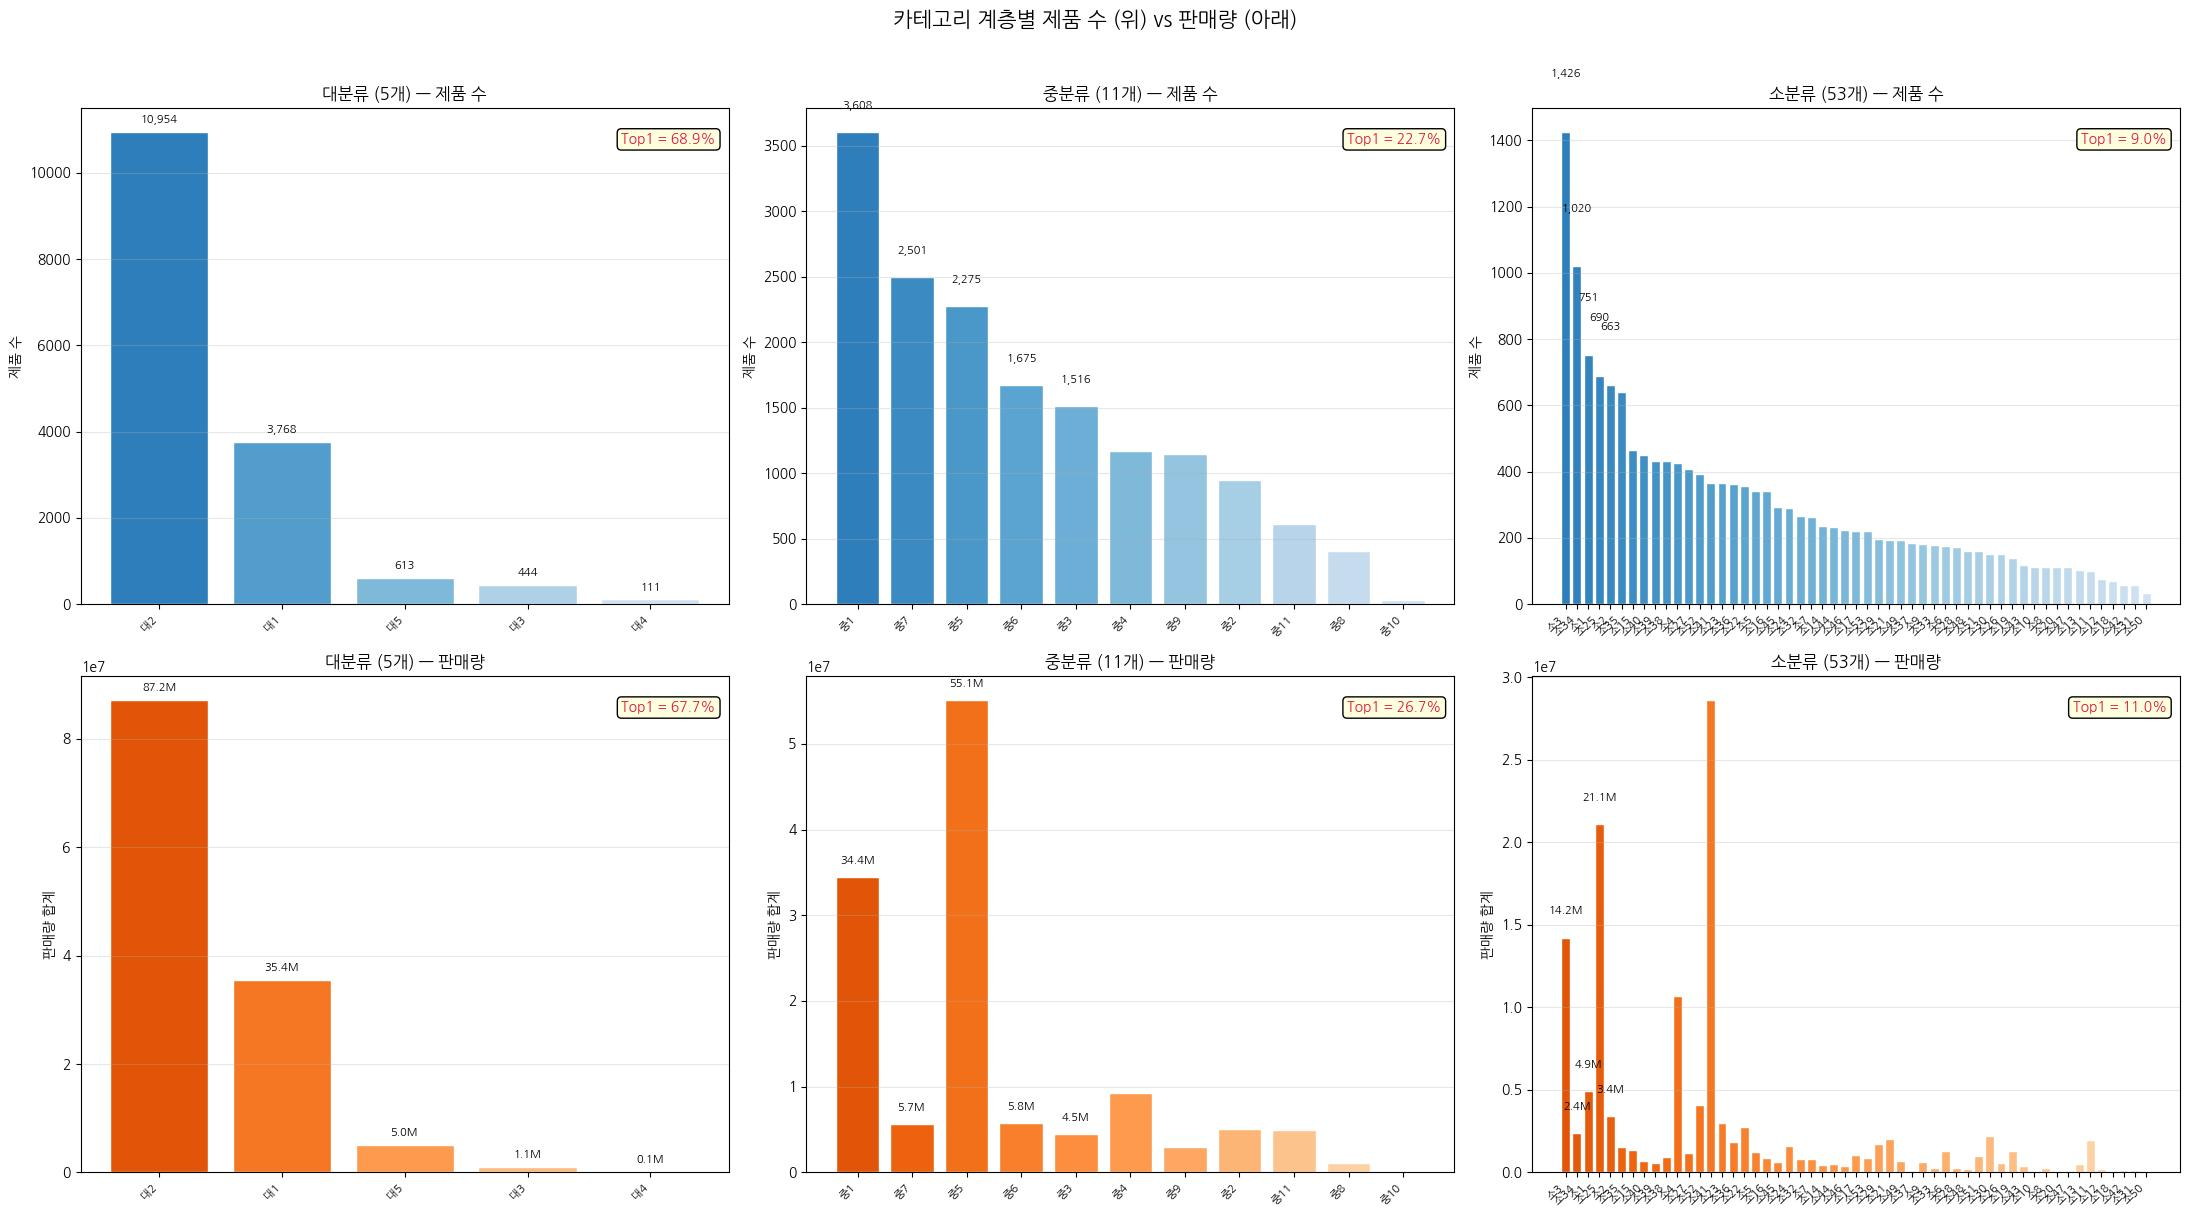

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [8]:
# ══════════════════════════════════════════════════════════════
# 1-1-B. 카테고리 구조 시각화 — 제품 수 + 판매량 동시 비교 (수정)
# ══════════════════════════════════════════════════════════════
# 레이아웃:
#   위 3개: 대/중/소분류별 제품 수
#   아래 3개: 대/중/소분류별 판매량
#   → 위아래로 비교하면 "제품은 많은데 안 팔리는 카테고리" 한눈에 발견

DATE_COLS = [c for c in train.columns if c.startswith('20')]

# ── (수정) 카테고리 짧은 레이블 생성 ──────────────────────────────────
# 'B002-C001-0002' → '대2', 'B002-C002-0011' → '중11', 'B002-C003-0038' → '소38'
def short_label(code, prefix):
    number = code.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code: short_label(code, prefix)
        for code in train[col].unique()
    }

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):

    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt  = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)\
                        .reindex(product_cnt.index)

    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()

    # ── (수정) 짧은 레이블 적용 ───────────────────────────────
    # 기존: f'{name[:6]}'  → 코드 앞 6글자라 의미없이 잘림
    # 변경: cat_labels 딕셔너리로 '대2', '중11', '소38' 형태로 변환
    xlabels = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ───────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n-1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values,
                             color=colors_top, edgecolor='white')

    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}', ha='center', va='bottom', fontsize=8)

    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top',
                fontsize=10, color='crimson',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수', fontsize=10)
    ax_top.set_xticks(range(n))
    # ── (수정) 소분류(53개)도 레이블 표시 — 짧아졌으니 가능
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')

    # ── 아래: 판매량 ──────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n-1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values,
                                color=colors_bot, edgecolor='white')

    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        if j < 5:
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

    top1_sales_pct = sales_by_cat.values[0] / total_sales * 100
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top',
                   fontsize=10, color='crimson',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계', fontsize=10)
    ax_bottom.set_xticks(range(n))
    # ── (수정) 동일하게 짧은 레이블 적용
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────
print("=" * 60)
print("📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개")
print("=" * 60)
for col in cats:
    print(f"\n[{col}]")
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)

    summary = pd.DataFrame({
        '제품수'       : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'       : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)

    # ── (수정) 인덱스(코드)도 짧은 레이블로 변환해서 출력
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())


#### 💬 1-1-B 해석 — 카테고리 불균형이 모델 설계에 미치는 영향 (수정完)
🔍 핵심 발견: 제품 수 ≠ 판매량 (카테고리 간 비교)

| 카테고리 | 제품수 비율 | 판매 비율 | 해석 |
|---------|-----------|---------|------|
| 대분류 대2 | 68.9% | 67.7% | 합산 기준 두 비율 유사 → 카테고리 간 불균형은 적음 |
| 중분류 중5 | 14.3% | 42.8% | 제품은 적은데 판매 압도적 → 핵심 카테고리 |
| 소분류 소41 | 2.3% | 22.2% | 제품 극소수인데 판매 1위 → 스타 카테고리 |

> ⚠️ 카테고리 내부에서 소수 제품이 판매를 주도하는지는
> 별도 분석(1-2 Long Tail)에서 확인

> 📌 카테고리 불균형 수치는 이후 임베딩 차원 결정에 활용
> (STEP 3 모델 설계 섹션 참고)

```

### 1-2. 판매량 분포 — Long Tail 확인

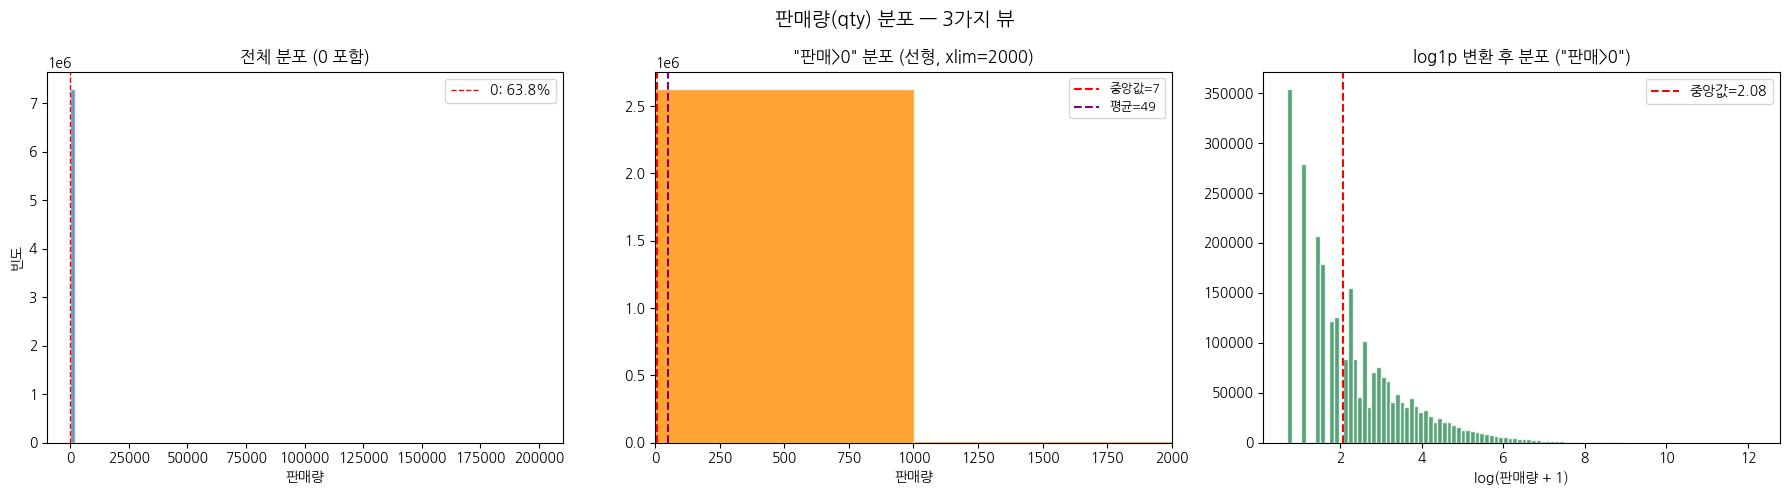


💡 정리: 원본 범위 0~200,420  →  log 변환 후 0~12.2
   스케일 압축 비율: 16417배 축소


In [9]:
# 전체 분포 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('판매량(qty) 분포 — 3가지 뷰', fontsize=14, fontweight='bold')

qty_all   = train[DATE_COLS].values.flatten()
qty_nonzero = qty_all[qty_all > 0]

# ── 그래프 1: 전체 분포 (0 포함) ──────────────────────────────────────────
ax = axes[0]
ax.hist(qty_all, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('전체 분포 (0 포함)')
ax.set_xlabel('판매량')
ax.set_ylabel('빈도')
ax.axvline(0, color='red', ls='--', lw=1, label=f'0: {(qty_all==0).mean():.1%}')
ax.legend()

# ── 그래프 2: 판매>0인 날만 (선형 스케일) ─────────────────────────────────
ax = axes[1]
ax.hist(qty_nonzero, bins=200, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlim(0, 2000)   # 극단값 제외하고 시각화
ax.set_title('"판매>0" 분포 (선형, xlim=2000)')
ax.set_xlabel('판매량')
ax.axvline(np.median(qty_nonzero), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_nonzero):.0f}')
ax.axvline(qty_nonzero.mean(), color='purple', ls='--', lw=1.5,
           label=f'평균={qty_nonzero.mean():.0f}')
ax.legend(fontsize=9)

# ── 그래프 3: Log 변환 후 분포 ─────────────────────────────────────────────
ax = axes[2]
qty_log = np.log1p(qty_nonzero)
ax.hist(qty_log, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_title('log1p 변환 후 분포 ("판매>0")')
ax.set_xlabel('log(판매량 + 1)')
ax.axvline(np.median(qty_log), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_log):.2f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n💡 정리: 원본 범위 0~{qty_all.max():,}  →  log 변환 후 0~{np.log1p(qty_all.max()):.1f}")
print(f"   스케일 압축 비율: {qty_all.max() / np.log1p(qty_all.max()):.0f}배 축소")

#### 💬 1-2 해석

**그래프 1**: 전체의 63.8%가 0 → 왼쪽에 엄청난 뭉치  
**그래프 2**: 판매가 있는 날만 봐도(판매>0) 0에 긴 막대기가 세워짐.(오른쪽으로 극단적으로 긴 꼬리 (최대 200,420개))  
=> xlim=2000으로 2000개까지만 잘라서 봄(너무 차이가 큰 제품들은 빼고 보는 것-이상치)  
평범한 판매량을 보려한건데도 판매량이 1000이하에 몰려있어서 벽돌같은 모양으로 그래프가 그려짐

**그래프 3**: `log(x+1)` 변환 후 종 모양에 가까워짐 / 전체 데이터의 절반(50%)은 2.08보다 왼쪽이라는 좁은 구간에 오밀조밀 빽빽하게 뭉쳐있고, 나머지 절반(50%)의 대박 난 날들은 2.08 오른쪽으로 넓고 듬성듬성 퍼져있음

**Log 변환 전후비교:**
| 변환 전 | 변환 후 |  
|--------|--------|  
| 범위 0 ~ 200,420 (차이 20만배) | 범위 0 ~ 12.2 (차이 12배) |
| 인기 제품 하나가 학습 전체를 지배 | 모든 제품이 비슷한 영향력 |
| 모델이 불안정하게 학습 | 안정적인 gradient 흐름 |  

> **역변환**: 예측 완료 후 `np.expm1(y) = exp(y)-1`로 원래 단위(개)로 복원  

1-2-B. 카테고리 내부 Long Tail 확인 — 수치 + 그래프

📌 대분류별 내부 판매 집중도
   (상위 10% 제품이 해당 카테고리 판매의 몇 %를 차지하나?)

  대2 (제품 10,954개)
    상위  1% 제품(109개) → 판매의 49.3% 차지
    상위 10% 제품(1095개) → 판매의 84.9% 차지

  대1 (제품 3,768개)
    상위  1% 제품( 37개) → 판매의 49.4% 차지
    상위 10% 제품(376개) → 판매의 82.2% 차지

  대5 (제품 613개)
    상위  1% 제품(  6개) → 판매의 25.9% 차지
    상위 10% 제품( 61개) → 판매의 73.5% 차지

  대3 (제품 444개)
    상위  1% 제품(  4개) → 판매의 24.1% 차지
    상위 10% 제품( 44개) → 판매의 58.0% 차지

  대4 (제품 111개)
    상위  1% 제품(  1개) → 판매의 12.8% 차지
    상위 10% 제품( 11개) → 판매의 51.1% 차지


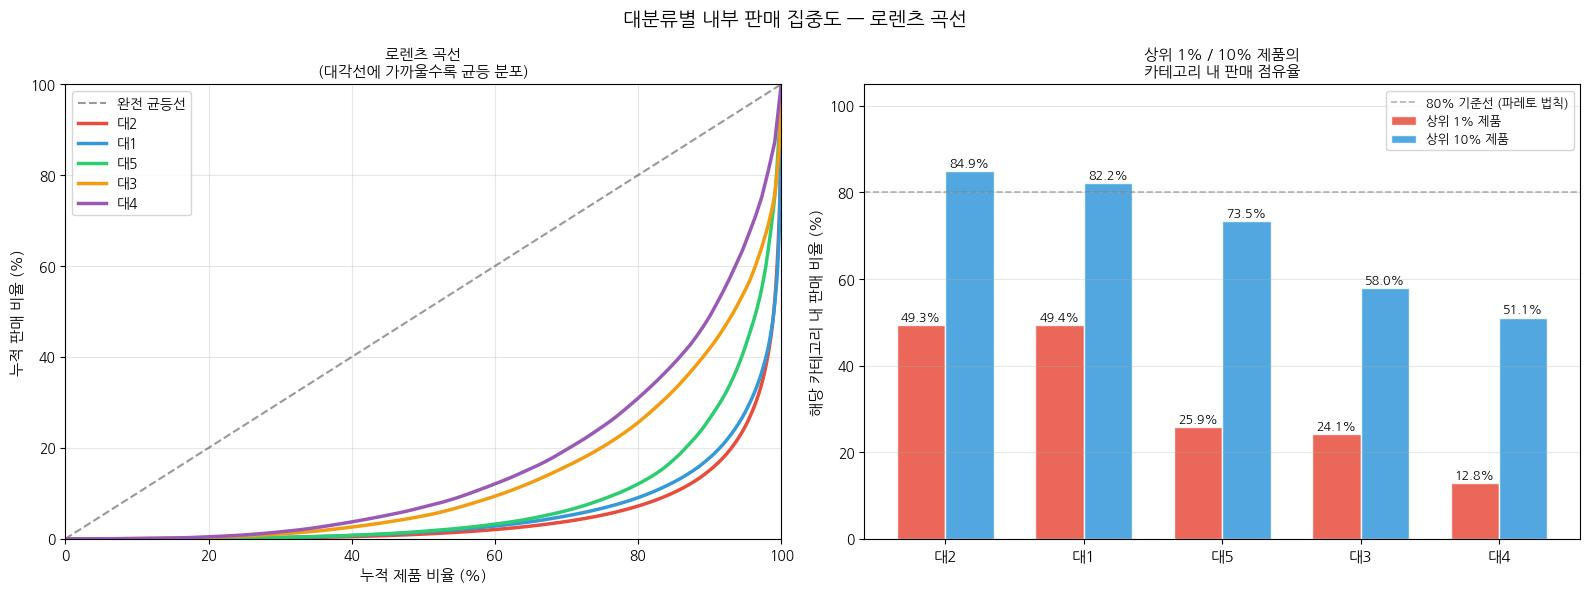

In [10]:
# ══════════════════════════════════════════════════════════════
# 1-2-B. 카테고리 내부 Long Tail 확인 — 수치 + 그래프
# ══════════════════════════════════════════════════════════════
# 목적:
#   1-1-B에서 발견: "대2가 제품 68.9%, 판매 67.7% → 비슷해 보임"
#   근데 내부적으로도 고른건지, 소수 제품이 판매를 주도하는건지 모름
#   → 각 대분류 안에서 "상위 N% 제품이 판매의 몇 %를 차지하나?" 확인
#   → 로렌츠 곡선: 완전 균등이면 대각선, 불균형할수록 아래로 처짐

DATE_COLS = [c for c in train.columns if c.startswith('20')]
train['total_sales'] = train[DATE_COLS].sum(axis=1)

# ── 수치 출력 ──────────────────────────────────────────────────
print("=" * 60)
print("📌 대분류별 내부 판매 집중도")
print("   (상위 10% 제품이 해당 카테고리 판매의 몇 %를 차지하나?)")
print("=" * 60)

cats_ordered = train.groupby('대분류')['total_sales'].sum()\
                    .sort_values(ascending=False).index

for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1   = subset.iloc[:max(1, int(len(subset) * 0.01))].sum()
    top10  = subset.iloc[:max(1, int(len(subset) * 0.1))].sum()
    label  = cat_labels['대분류'].get(cat, cat)

    print(f"\n  {label} (제품 {len(subset):,}개)")
    print(f"    상위  1% 제품({max(1,int(len(subset)*0.01)):3d}개) → 판매의 {top1/total*100:.1f}% 차지")
    print(f"    상위 10% 제품({max(1,int(len(subset)*0.1)):3d}개) → 판매의 {top10/total*100:.1f}% 차지")

# ── 그래프: 로렌츠 곡선 ───────────────────────────────────────
# 로렌츠 곡선이란?
#   X축: 제품을 판매량 적은 순서로 줄 세웠을 때 누적 제품 비율 (0~100%)
#   Y축: 그 제품들의 누적 판매 비율 (0~100%)
#   완전 균등: 대각선 (제품 10%가 판매 10% 담당)
#   불균형할수록 곡선이 아래로 처짐
#   → 곡선이 대각선에서 멀수록 "소수 제품이 판매를 독식"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('대분류별 내부 판매 집중도 — 로렌츠 곡선',
             fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# ── 왼쪽: 대분류별 로렌츠 곡선 ───────────────────────────────
ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, alpha=0.4, label='완전 균등선')

for i, cat in enumerate(cats_ordered):
    subset = train[train['대분류'] == cat]['total_sales']\
                  .sort_values(ascending=True).values  # 적은 순 정렬
    total  = subset.sum()
    cumsum = np.cumsum(subset) / total * 100
    x      = np.linspace(0, 100, len(cumsum))
    label  = cat_labels['대분류'].get(cat, cat)
    ax.plot(x, cumsum, color=colors[i], linewidth=2.5, label=label)

ax.set_xlabel('누적 제품 비율 (%)', fontsize=11)
ax.set_ylabel('누적 판매 비율 (%)', fontsize=11)
ax.set_title('로렌츠 곡선\n(대각선에 가까울수록 균등 분포)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# ── 오른쪽: 상위 1% / 10% 판매 비율 막대 비교 ────────────────
ax = axes[1]

labels_list = [cat_labels['대분류'].get(c, c) for c in cats_ordered]
top1_pcts   = []
top10_pcts  = []

for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1_pcts.append(subset.iloc[:max(1, int(len(subset)*0.01))].sum() / total * 100)
    top10_pcts.append(subset.iloc[:max(1, int(len(subset)*0.1))].sum() / total * 100)

x    = np.arange(len(labels_list))
width = 0.35

bars1 = ax.bar(x - width/2, top1_pcts,  width, label='상위 1% 제품',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top10_pcts, width, label='상위 10% 제품',
               color='#3498db', alpha=0.85, edgecolor='white')

# 숫자 표시
for bar, val in zip(bars1, top1_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 80% 기준선 (실무에서 "파레토 법칙" 기준)
ax.axhline(80, color='gray', linestyle='--', linewidth=1.2, alpha=0.6,
           label='80% 기준선 (파레토 법칙)')

ax.set_xticks(x)
ax.set_xticklabels(labels_list, fontsize=11)
ax.set_ylabel('해당 카테고리 내 판매 비율 (%)', fontsize=11)
ax.set_title('상위 1% / 10% 제품의\n카테고리 내 판매 점유율', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

train.drop(columns=['total_sales'], inplace=True)

**파레토 법칙(Pareto Principle)**  
전체 결과의 80%가 전체 원인의 20%에서 일어난다는 현상을 말합니다. 흔히 **'80대 20 법칙'**이라고도 함

#### 🔍 1-2-B 확인 : 카테고리 내부도 Long Tail

| 대분류 | 상위 1% 제품 | 상위 10% 제품 | 파레토(80%) 초과? |
|-------|------------|-------------|----------------|
| 대2 | 49.3% | 84.9% | ✅ 초과 |
| 대1 | 49.4% | 82.2% | ✅ 초과 |
| 대5 | 25.9% | 73.5% | ❌ 미달 |
| 대3 | 24.1% | 58.0% | ❌ 미달 |
| 대4 | 12.8% | 51.1% | ❌ 미달 |

→ **모든 카테고리 내부가 Long Tail 구조**
→ 대2, 대1은 특히 심함: 상위 1% 제품 100개 내외가 판매의 절반 담당
→ 1-2 전체 판매량 분포와 동일한 패턴 확인

### 1-3. 일별 판매 트렌드 — 전체 흐름 파악

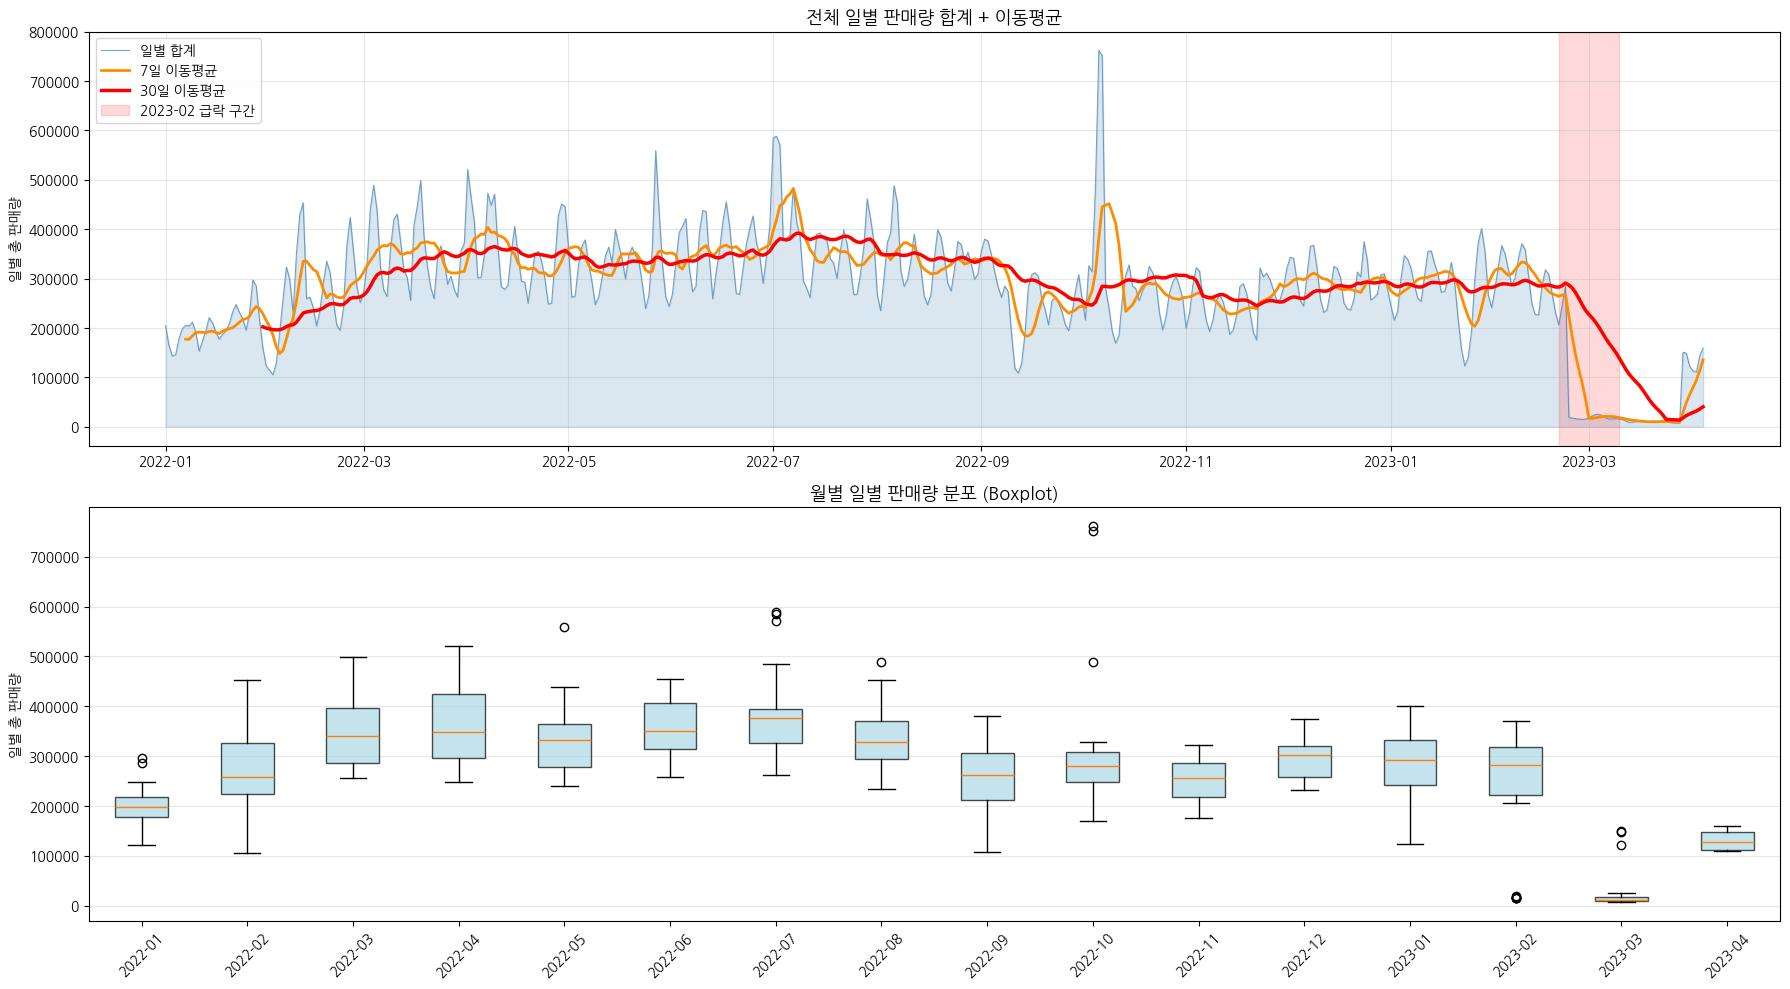

In [11]:
# ── 전체 일별 판매량 합산 ────────────────────────────────────────────────────
# axis=0: 행(제품) 방향으로 합산 → 날짜별 전체 판매량
daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

# 이동평균(Moving Average): 지정한 기간의 평균을 날짜별로 계산
# 7일 이동평균 = 오늘 포함 최근 7일의 평균 → 요일 주기 잡음 제거
# 30일 이동평균 = 큰 흐름(트렌드)만 부각
ma7  = daily_total.rolling(7).mean()
ma30 = daily_total.rolling(30).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# ── 위 그래프: 원본 + 이동평균 ─────────────────────────────────────────────
ax = axes[0]
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=0.8,
        alpha=0.7, label='일별 합계')
ax.plot(ma7.index,  ma7.values,  color='darkorange', lw=2, label='7일 이동평균')
ax.plot(ma30.index, ma30.values, color='red',        lw=2.5, label='30일 이동평균')

# 주목할 구간 표시
ax.axvspan(pd.Timestamp('2023-02-20'), pd.Timestamp('2023-03-10'),
           alpha=0.15, color='red', label='2023-02 급락 구간')
ax.set_title('전체 일별 판매량 합계 + 이동평균', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ── 아래 그래프: 월별 박스플롯 ────────────────────────────────────────────
# 월별로 일별 판매량의 분포(최소~최대, 중앙값)를 한눈에 확인
ax = axes[1]
temp = pd.DataFrame({'date': daily_total.index, 'total': daily_total.values})
temp['yearmonth'] = temp['date'].dt.strftime('%Y-%m')
month_data = [group['total'].values for _, group in temp.groupby('yearmonth')]
month_labels = temp['yearmonth'].unique()

ax.boxplot(month_data, labels=month_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('월별 일별 판매량 분포 (Boxplot)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


#### 💬 1-3 해석 — 트렌드에서 발견한 것들

| 구간 | 현상 | 해석 | 전처리 영향 |
|------|------|------|------------|
| 2022-01 ~ 2022-12 | 전반적 우상향 + 이벤트 급등 | 정상 성장 + 특정 이벤트(11.11, 설 등) | 이벤트 피처 추가 검토 |
| 2023-02-23 이후 | 판매량 급격 하락 | 단순 spike가 아닌 **구조적 레벨 변화** | 새 레벨을 정상으로 인식하도록 regime_flag 추가 |

---

⚠️ 2023-02-23 급락 — 레짐 변화(Regime Change)

이 지점 이후 판매량 레벨이 **통째로** 내려감
특정 제품 1개의 문제가 아니라 **전체 제품에 걸친 구조적 변화**

박스플롯에서도 확인됨
- 2023-02: 박스는 정상 레벨 유지, 아래 이상치 점 존재
  → 2월 대부분은 정상, 월 말 5~6일만 급락
- 2023-03: 박스 전체가 낮은 레벨로 내려앉음
  → 월 전체가 새로운 낮은 레벨로 안착
- 2023-04: 비슷한 낮은 레벨 유지
  → 예측 기간도 이 레벨 지속 가능성 높다고 추측

예측 기간(2023-04-05~25)이 이 낮은 레벨 이후에 해당해서
**2023년 3월 데이터를 학습에 반드시 포함**해야 함

---

📌 regime_flag 필요한 이유 요약
```
is_post_regime = 0  (2023-02-22 이전)
is_post_regime = 1  (2023-02-23 이후)
```

lag 피처(qty_lag_7, qty_lag_28 등)가 "최근 판매 레벨"을 이미 담고 있지만,
세 가지 이유로 명시적 flag가 추가로 필요함

**이유 1: 비용이 거의 없음**  
이진 컬럼 하나 추가가 전부임

**이유 2: 신호가 강하고 명확함**  
급락 날짜가 2023-02-23으로 특정됐고,  
예측 기간 21일이 전부 `is_post_regime = 1` 구간에 속함  
모델에게 "지금은 낮은 레벨이 정상이다"라고 명시적으로 알려주는 효과가 있음  

**이유 3: 급락 시점을 걸쳐가는 학습 샘플 보호**  
입력 윈도우가 2023-02-10 ~ 03-09처럼 급락 전후를 모두 포함하는 샘플은  
lag 피처 안에서 판매량이 뚝 떨어지는 구간이 생김  
`regime_flag`가 없으면 모델이 이걸 "갑자기 튀는 노이즈"로 오해할 수 있음  
flag가 있으면 "아, 이 시점부터 레벨이 바뀐 거구나"를 학습할 수 있음  

> 전처리 "날짜 피처" 생성 시 사용하기

### 1-4. 요일·월별 판매 패턴 — 날짜 피처 설계 근거

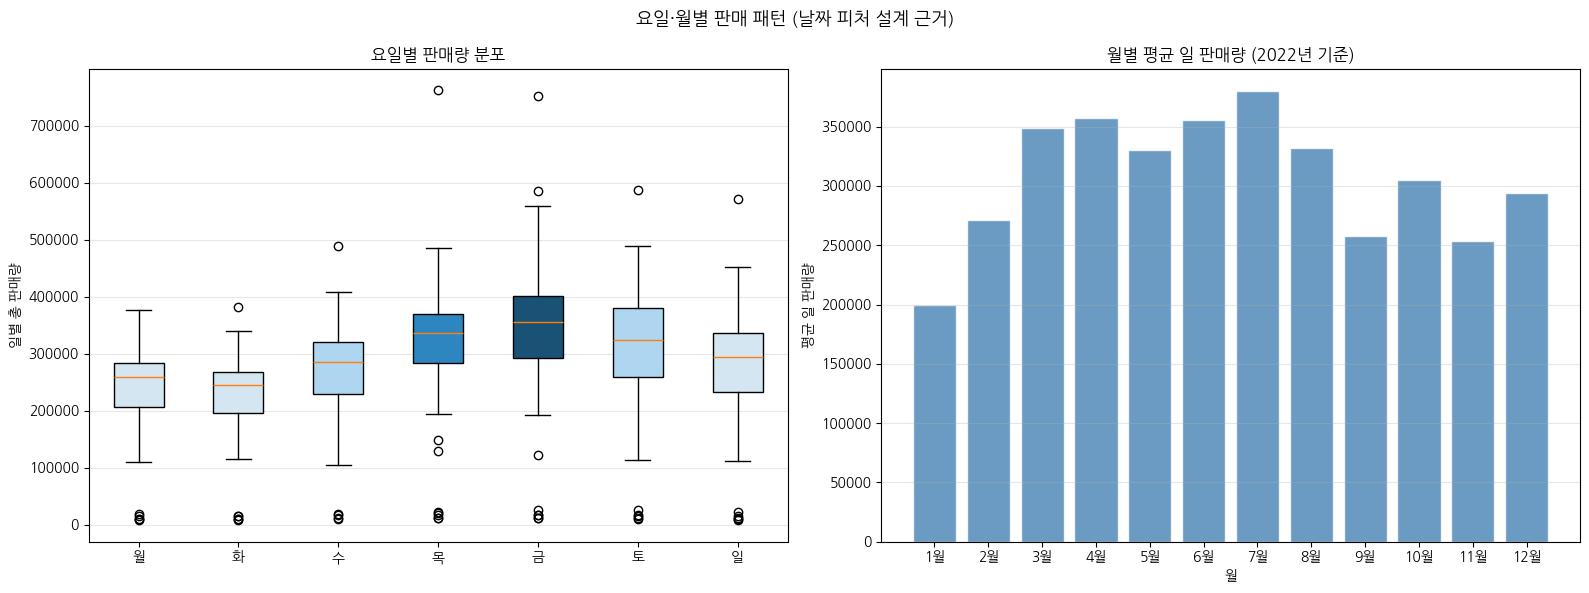


요일별 중앙값 (월=0 ~ 일=6):
  월요일: 259,226
  화요일: 245,395
  수요일: 285,849
  목요일: 336,110
  금요일: 356,167
  토요일: 324,333
  일요일: 294,432


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('요일·월별 판매 패턴 (날짜 피처 설계 근거)', fontsize=13, fontweight='bold')

temp = pd.DataFrame({'date': pd.to_datetime(daily_total.index),
                     'total': daily_total.values})
temp['day_of_week'] = temp['date'].dt.dayofweek          # 0=월, 6=일
temp['month']       = temp['date'].dt.month
dow_labels = ['월', '화', '수', '목', '금', '토', '일']

# ── 왼쪽: 요일별 Boxplot ──────────────────────────────────────────────────
ax = axes[0]
dow_data = [temp[temp['day_of_week']==d]['total'].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, patch_artist=True)
colors = ['#d4e6f1','#d4e6f1','#aed6f1','#2e86c1','#1a5276','#aed6f1','#d4e6f1']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
ax.set_title('요일별 판매량 분포')
ax.set_ylabel('일별 총 판매량')
ax.grid(alpha=0.3, axis='y')

# ── 오른쪽: 월별 평균 라인차트 ────────────────────────────────────────────
ax = axes[1]
# 2023-02 급락 영향을 제거하기 위해 2022년만 따로 확인
temp_2022 = temp[temp['date'].dt.year == 2022]
monthly_avg = temp_2022.groupby('month')['total'].mean()
month_labels_12 = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8,
       edgecolor='white')
ax.set_title('월별 평균 일 판매량 (2022년 기준)')
ax.set_xlabel('월')
ax.set_ylabel('평균 일 판매량')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels_12)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 수치로도 확인
print("\n요일별 중앙값 (월=0 ~ 일=6):")
for d, label in enumerate(dow_labels):
    median = temp[temp['day_of_week']==d]['total'].median()
    print(f"  {label}요일: {median:,.0f}")


#### 💬 1-4 해석 — 날짜 피처 설계

* 레짐 급락은 따로 떨어뜨려놓고 볼거기 때문에 2022년만 봤음

**요일 패턴**  

| 구분 | 요일 | 중앙값 |
|------|------|--------|
| 고판매 | 목·금·토 | 324,333 ~ 356,167 |
| 중간   | 일       | 294,432 | 
| 저판매 | 월·화·수 | 245,395 ~ 285,849 |  

→ 목~토 쇼핑 집중, 월~수 침체  
→ 단순 '평일/주말' 구분으로는 이 패턴을 못 잡음  
→ `day_of_week` (0~6) 자체를 피처로 써야 함  
→ 하지만 `is_weekend` 피쳐도 보조역할로 넣어볼 예정  

**월 패턴 (2022년 기준):**  
- 1~2월: 낮은 출발 (연초 침체)  
- 3~7월: 상승 구간, 7월 최고점  
- 8~12월: 하락 후 유지  
- 전반적으로 **중반기(3~7월)가 가장 높고, 연초·연말이 낮음**  

→ 뚜렷한 계절성 존재 → `month` 피처 필요  

**STEP 2에서 만들 날짜 피처 목록:**  
```python  
day_of_week  = 0~6  (요일)
day_of_month = 1~31 (월 내 날짜)
month        = 1~12 (월)
week_of_year = 1~52 (연 내 주)
is_weekend   = 0/1  (주말 여부)
is_post_regime = 0/1 (2023-02-23 기준 레짐 변화)  # 1-3에서 결정
```

### 1-5. 0의 2가지 종류 구분 — 구조적 0 vs 진짜 0

> 이 단계는 EDA 중 **가장 중요한 분석** ✨  
> 0이라는 숫자가 두 가지 전혀 다른 의미를 가지고 있기 때문임  

| 종류 | 언제 발생? | 실제 의미 | 학습에 포함해야 하나? |
|------|----------|---------|---------------------|
| **구조적 0** | 제품 출시 전 | "아직 존재하지 않는 제품" | ❌ 제외 |
| **진짜 0** | 출시 후인데 그날 판매 없음 | "그날 아무도 안 샀음" | ✅ 포함 |

In [13]:
# ══════════════════════════════════════════════════════════════
# 1-5-A. 제품별 첫/마지막 판매일 계산 + 0 종류 분류
# ══════════════════════════════════════════════════════════════
# 목적:
#   판매량 = 0인 셀이 두 가지 의미를 가짐
#   (1) 구조적 0: 첫 판매일 이전 → "이 제품은 아직 존재하지 않음" → 학습 제외
#   (2) 진짜 0:   첫 판매일 이후 → "오늘은 아무도 안 샀음"       → 학습 포함
#
#   한 번도 안 팔린 제품(85개): train은 건드리지 않음
#   → ID만 never_sold_ids로 기록 → 제출 시 예측값 0으로 채움
#   단종 기준(N일) 없음 → days_since_last_sale 피처로 모델이 스스로 판단

DATE_COLS = [c for c in train.columns if c.startswith('20')]
qty_arr   = train[DATE_COLS]

# ── 한 번이라도 판매된 적 있는지 ─────────────────────────────────────────
has_sales = (qty_arr > 0).any(axis=1)

# 한 번도 안 팔린 제품 ID만 기록 (train은 건드리지 않음)
# → 학습/전처리에서는 EXCLUDE_IDS로 제외
# → 제출 시 해당 ID 예측값 = 0으로 채움
never_sold_ids = set(train.loc[~has_sales, 'ID'].values)
print(f"한 번도 안 팔린 제품: {len(never_sold_ids)}개 → 제출 시 예측값 0으로 채울 예정")

# ── 첫/마지막 판매일 계산 (판매 있는 제품만) ──────────────────────────────
# idxmax: True/False 배열에서 처음 True인 컬럼명 반환
first_sale_col = (qty_arr > 0).idxmax(axis=1)
# 뒤집어서 idxmax → 마지막 True인 컬럼명 반환
last_sale_col  = (qty_arr > 0).iloc[:, ::-1].idxmax(axis=1)

train['first_sale_date'] = pd.to_datetime(first_sale_col)
train['last_sale_date']  = pd.to_datetime(last_sale_col)

# 한 번도 안 팔린 제품은 NaT 처리
train.loc[~has_sales, ['first_sale_date', 'last_sale_date']] = pd.NaT

# ── 0 종류 분류 ────────────────────────────────────────────────────────────
total_cells      = len(train) * len(DATE_COLS)
sold_cells       = (qty_arr > 0).sum().sum()
date_index       = pd.to_datetime(DATE_COLS)
structural_zeros = 0

for _, row in train[has_sales].iterrows():
    # 출시 전만 구조적 0 (단종 N일 기준 없음)
    pre_launch        = (date_index < row['first_sale_date']).sum()
    structural_zeros += pre_launch

real_zeros = total_cells - sold_cells - structural_zeros

print("=" * 55)
print("📊 0의 두 종류 분류 결과")
print("=" * 55)
print(f"  전체 셀 수             : {total_cells:>10,}개 (100.0%)")
print(f"  실제 판매 (qty > 0)    : {sold_cells:>10,}개 ({sold_cells/total_cells:.1%})")
print(f"  진짜 0 (출시 후 미판매): {real_zeros:>10,}개 ({real_zeros/total_cells:.1%})")
print(f"  구조적 0 (출시 전)     : {structural_zeros:>10,}개 ({structural_zeros/total_cells:.1%})")
print()
print(f"  한 번도 안 팔린 제품   : {len(never_sold_ids):>10,}개 → 제출 시 0 처리")
print(f"  활성 기간 49일 미만    : {((qty_arr > 0).sum(axis=1) < 49).sum():>10,}개")
print()
print("💡 SEQ_LEN(28) + PRED_LEN(21) = 49일 → 최소 필요 활성 기간")

한 번도 안 팔린 제품: 85개 → 제출 시 예측값 0으로 채울 예정
📊 0의 두 종류 분류 결과
  전체 셀 수             :  7,293,510개 (100.0%)
  실제 판매 (qty > 0)    :  2,640,650개 (36.2%)
  진짜 0 (출시 후 미판매):  3,241,416개 (44.4%)
  구조적 0 (출시 전)     :  1,411,444개 (19.4%)

  한 번도 안 팔린 제품   :         85개 → 제출 시 0 처리
  활성 기간 49일 미만    :      4,820개

💡 SEQ_LEN(28) + PRED_LEN(21) = 49일 → 최소 필요 활성 기간


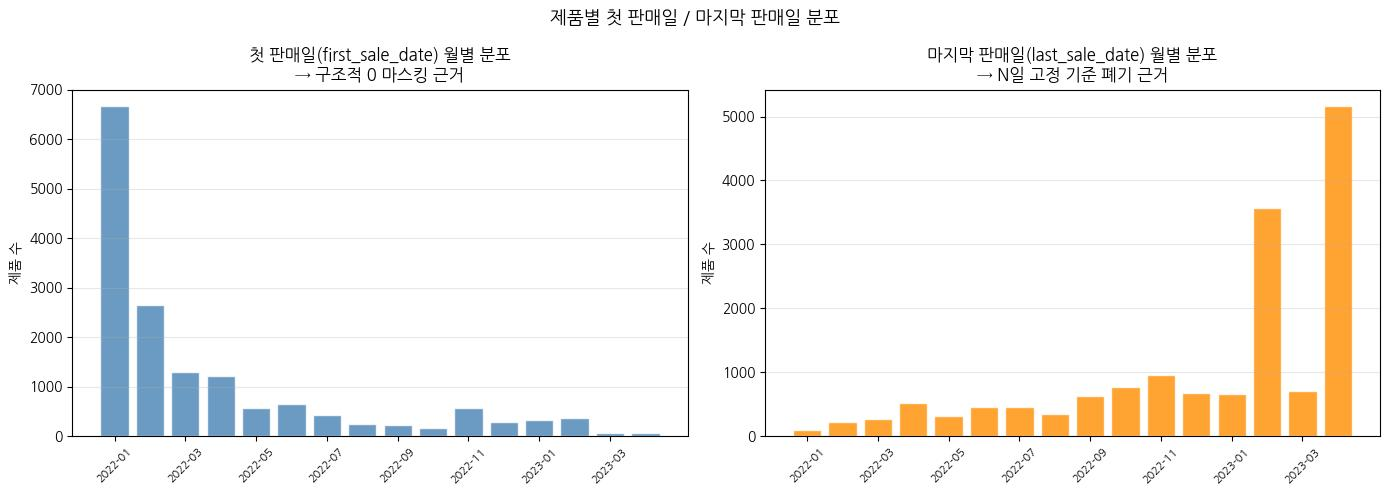

💡 마지막 판매일이 2023-03~04에 집중된 이유:
   레짐 급락(2023-02-23) 이후 판매가 끊긴 제품들이 몰린 것
   → 이걸 전부 단종으로 처리하면 멀쩡한 제품까지 제거됨
   → N일 고정 기준 대신 days_since_last_sale 피처로 모델이 판단하게 함


In [14]:
# ══════════════════════════════════════════════════════════════
# 1-5-B. 첫 판매일 / 마지막 판매일 분포 시각화
# ══════════════════════════════════════════════════════════════
# 목적:
#   (A) first_sale_date 분포 → 구조적 0 마스킹 근거
#   (B) last_sale_date 분포  → N일 고정 기준 폐기 근거
#       2023-03~04에 집중된 것은 레짐 급락 때문 → 단종이 아님

active = train[has_sales].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('제품별 첫 판매일 / 마지막 판매일 분포', fontsize=13, fontweight='bold')

# ── 왼쪽: first_sale_date 월별 히스토그램 ────────────────────────────────
ax = axes[0]
first_month = active['first_sale_date'].dt.to_period('M').value_counts().sort_index()
ax.bar(range(len(first_month)), first_month.values,
       color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xticks(range(0, len(first_month), 2))
ax.set_xticklabels([str(p) for p in first_month.index[::2]], rotation=45, fontsize=8)
ax.set_title('첫 판매일(first_sale_date) 월별 분포\n→ 구조적 0 마스킹 근거')
ax.set_ylabel('제품 수')
ax.grid(alpha=0.3, axis='y')

# ── 오른쪽: last_sale_date 월별 히스토그램 ───────────────────────────────
ax = axes[1]
last_month = active['last_sale_date'].dt.to_period('M').value_counts().sort_index()
ax.bar(range(len(last_month)), last_month.values,
       color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xticks(range(0, len(last_month), 2))
ax.set_xticklabels([str(p) for p in last_month.index[::2]], rotation=45, fontsize=8)
ax.set_title('마지막 판매일(last_sale_date) 월별 분포\n→ N일 고정 기준 폐기 근거')
ax.set_ylabel('제품 수')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("💡 마지막 판매일이 2023-03~04에 집중된 이유:")
print("   레짐 급락(2023-02-23) 이후 판매가 끊긴 제품들이 몰린 것")
print("   → 이걸 전부 단종으로 처리하면 멀쩡한 제품까지 제거됨")
print("   → N일 고정 기준 대신 days_since_last_sale 피처로 모델이 판단하게 함")

#### 💬 1-5 해석 — 0 처리 결론

📊 숫자로 본 결과

| 구분 | 셀 수 | 비율 | 학습 여부 |
|------|-------|------|---------|
| 실제 판매 (qty > 0) | 2,640,650개 | 36.2% | ✅ 포함 |
| 진짜 0 (출시 후 미판매) | 3,241,416개 | 44.4% | ✅ 포함 |
| 구조적 0 (출시 전) | 1,411,444개 | 19.4% | ❌ 제외 |

→ 모델이 실제로 보는 데이터: **5,882,066개 (80.6%)**
→ 이 중 실제 판매가 있는 날: **44.9%**

---

📈 그래프에서 발견한 것

**첫 판매일 분포 (왼쪽):**
2022-01에 6,600개 이상 집중 → 데이터 시작 시점에 이미 판매 중이던 제품들
이후 월별 200~600개씩 꾸준히 신제품 출시

**마지막 판매일 분포 (가운데):**
2023-03~04에 급격히 집중 → 레짐 급락 이후 판매가 끊긴 제품들이 몰림
이걸 모두 "단종"으로 처리하면 과도한 제거 → N일 기준 폐기한 이유

**경과 일수 분포 (오른쪽):**
0~14일: 5,570개 → 예측 직전까지 활발히 판매된 제품
90일+:  5,771개 (36.5%) → 오랫동안 판매 없음 → 모델이 알아서 0 예측하게 둠

---

✅ 최종 결론
```
구조적 0 (첫 판매일 이전)   → 학습 마스킹
진짜 0   (첫 판매일 이후)   → 학습 포함
단종 판단                   → days_since_last_sale 피처로 모델에게 위임
```

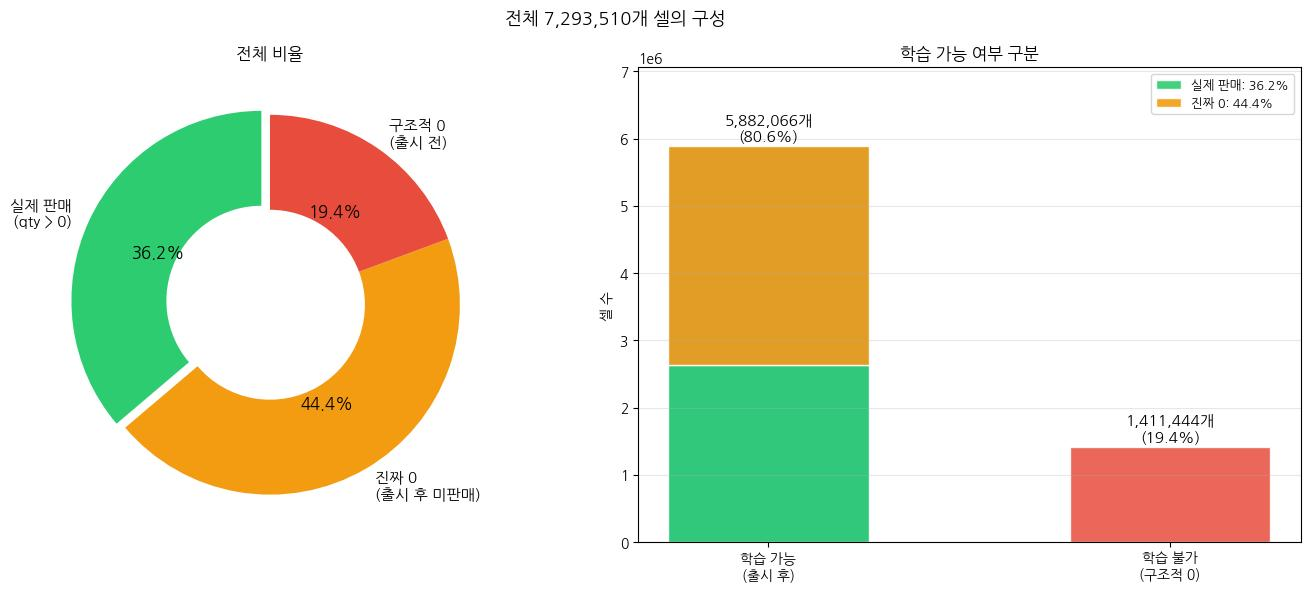


📌 결론: 전체 7,293,510개 중 구조적 0 1,411,444개(19.4%) 제거
   → 학습 가능 데이터: 5,882,066개 (80.6%)
   → 이 중 실제 판매: 44.9%


In [15]:
# ══════════════════════════════════════════════════════════════
# 1-5-C. 구조적 0 / 진짜 0 / 실제 판매 비율 시각화
# ══════════════════════════════════════════════════════════════
# 앞 셀(1-5-A)에서 계산한 숫자를 눈으로 확인
# (수정) 구조적 0 = 출시 전만 (단종 후 N일 기준 제거)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('전체 7,293,510개 셀의 구성', fontsize=13, fontweight='bold')

labels_pie = ['실제 판매\n(qty > 0)', '진짜 0\n(출시 후 미판매)', '구조적 0\n(출시 전)']
sizes      = [sold_cells, real_zeros, structural_zeros]
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
explode    = (0.05, 0, 0)

# ── 왼쪽: 도넛차트 ────────────────────────────────────────────────────────
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, colors=colors_pie, explode=explode,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('전체 비율', fontsize=12)

# ── 오른쪽: 학습 가능/불가 구분 ──────────────────────────────────────────
ax = axes[1]
usable     = sold_cells + real_zeros
not_usable = structural_zeros

bars = ax.bar(['학습 가능\n(출시 후)', '학습 불가\n(구조적 0)'],
              [usable, not_usable],
              color=['#3498db', '#e74c3c'], alpha=0.85, edgecolor='white', width=0.5)

ax.bar(['학습 가능\n(출시 후)'], [sold_cells],
       color='#2ecc71', alpha=0.9, edgecolor='white', width=0.5,
       label=f'실제 판매: {sold_cells/total_cells:.1%}')
ax.bar(['학습 가능\n(출시 후)'], [real_zeros],
       bottom=[sold_cells],
       color='#f39c12', alpha=0.9, edgecolor='white', width=0.5,
       label=f'진짜 0: {real_zeros/total_cells:.1%}')

for bar, val in zip(bars, [usable, not_usable]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50000,
            f'{val:,}개\n({val/total_cells:.1%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('학습 가능 여부 구분', fontsize=12)
ax.set_ylabel('셀 수')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, max(usable, not_usable) * 1.2)

plt.tight_layout()
plt.show()

print(f"\n📌 결론: 전체 {total_cells:,}개 중 구조적 0 {structural_zeros:,}개({structural_zeros/total_cells:.1%}) 제거")
print(f"   → 학습 가능 데이터: {usable:,}개 ({usable/total_cells:.1%})")
print(f"   → 이 중 실제 판매: {sold_cells/usable:.1%}")

### 1-6. Spike(이상치) 탐지 — 데이터 오류 vs 실제 이벤트 구분

감지된 Spike 날짜 수: 16일
날짜 목록: ['2022-02-10', '2022-02-11', '2022-04-01', '2022-04-29', '2022-04-30', '2022-05-27', '2022-07-01', '2022-07-02', '2022-07-03', '2022-08-06']


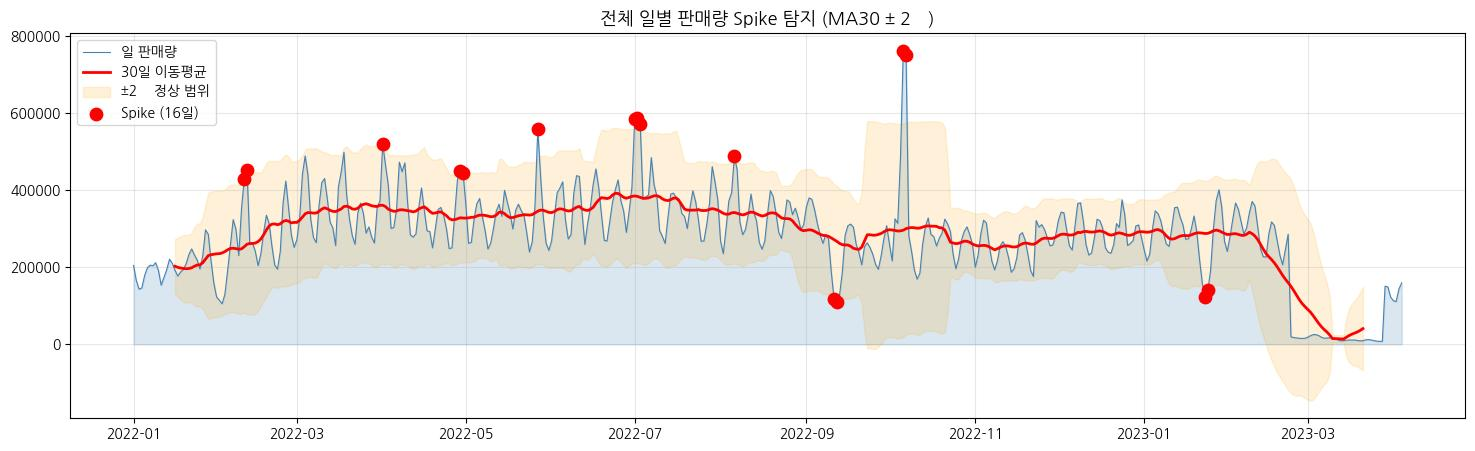

In [16]:
# ── Spike 탐지 로직 ──────────────────────────────────────────────────────
# 전체 일별 판매량 합계를 기준으로 이상하게 튀는 날짜를 찾습니다
# 왜 개별 제품 단위가 아니라 전체 합계로 볼까?
# → 한 제품의 데이터 오류가 전체 합계를 오염시키기 때문에
#   "이상한 날" 먼저 찾고, 그 날의 주범 제품을 특정하는 순서로 분석

daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

# ── 이상치 기준: MA30 ± 2σ ────────────────────────────────────────────────
# 중장기적인 추세 + 데이터가 정규분포를 따른다고 가정할 때, 전체의 95.4%가 이 범위 안에 들어옴
# MA30(30일 이동평균): 30일은 "요일 효과 + 단기 이벤트"를 흡수하면서 추세만 보여줌
# ±2σ: 정규분포 기준 약 95%는 이 안에 있어야 정상 → 5% 밖이면 이상
window  = 30
ma30    = daily_total.rolling(window, center=True).mean()
std30   = daily_total.rolling(window, center=True).std()
upper   = ma30 + 2 * std30
lower   = ma30 - 2 * std30

spike_dates = daily_total[(daily_total > upper) | (daily_total < lower)].index
print(f"감지된 Spike 날짜 수: {len(spike_dates)}일")
print(f"날짜 목록: {[str(d.date()) for d in spike_dates[:10]]}")

# ── Spike 날짜 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(daily_total.index, daily_total, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total, lw=0.8, color='steelblue', label='일 판매량')
ax.plot(ma30.index, ma30.values, 'r-', lw=2, label='30일 이동평균')
ax.fill_between(ma30.index, lower, upper, alpha=0.15, color='orange', label='±2σ 정상 범위')
ax.scatter(spike_dates, daily_total[spike_dates], color='red', zorder=5, s=80,
           label=f'Spike ({len(spike_dates)}일)')
ax.set_title('전체 일별 판매량 Spike 탐지 (MA30 ± 2σ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.show()


In [17]:
# ── Spike 날짜의 주범 제품 찾기 ──────────────────────────────────────────
# 각 Spike 날짜에서 판매량이 가장 많이 증가한 제품을 찾습니다
# 논리: 이상한 날의 전체 합계 - 그날 가장 많이 판 상위 제품들의 기여분을 분리

spike_contributors = {}  # {날짜: [제품ID 목록]}

for spike_dt in spike_dates:
    col = str(spike_dt.date())
    if col not in DATE_COLS:
        continue
    
    # 그날의 제품별 판매량 추출
    daily_row = train[['ID', col]].copy()
    daily_row.columns = ['ID', 'qty_today']
    
    # 해당 제품의 평소 중앙값 계산 (기준선)
    median_per_product = train[DATE_COLS].median(axis=1)
    daily_row['median_normal'] = median_per_product.values
    daily_row['excess'] = daily_row['qty_today'] - daily_row['median_normal']
    
    # 초과량 상위 5개 제품
    top5 = daily_row.nlargest(5, 'excess')[['ID', 'qty_today', 'median_normal', 'excess']]
    spike_contributors[col] = top5['ID'].tolist()

# 여러 Spike 날짜에 반복 등장하는 제품 확인
from collections import Counter
all_suspect = []
for ids in spike_contributors.values():
    all_suspect.extend(ids)
count = Counter(all_suspect)
print("Spike에 반복 등장한 제품 TOP 10:")
for prod_id, cnt in count.most_common(10):
    print(f"  제품 ID {prod_id}: {cnt}번 등장")


Spike에 반복 등장한 제품 TOP 10:
  제품 ID 12336: 8번 등장
  제품 ID 12347: 6번 등장
  제품 ID 12339: 4번 등장
  제품 ID 12340: 3번 등장
  제품 ID 4470: 3번 등장
  제품 ID 3846: 3번 등장
  제품 ID 3849: 3번 등장
  제품 ID 12351: 2번 등장
  제품 ID 12982: 2번 등장
  제품 ID 12284: 2번 등장


#### 💬 1-6 — Spike 처리 전략

🔍 결과

- 감지된 Spike 날짜: **16일**
- 반복 등장 제품:

| 제품 ID | 등장 횟수 | 해석 |
|--------|---------|------|
| 12336  | 8회 (16일 중 절반) | 데이터 오류 강하게 의심 |
| 12347  | 6회 | 데이터 오류 의심 |
| 12339  | 4회 | 의심 |
| 나머지  | 1~3회 | 실제 이벤트 가능성 |

→ **소수 제품이 Spike 날짜의 절반에 반복 등장**
→ 실제 이벤트라면 여러 제품이 고르게 등장해야 함
→ 12336, 12347 등 상위 제품은 데이터 오류로 판단

---

📐 처리 전략

| 상황 | 판단 | 처리 |
|------|------|------|
| 특정 제품이 Spike 날짜에 반복 등장 | 데이터 오류 가능성 높음 | **클리핑** |
| 여러 제품이 산발적으로 등장 | 실제 이벤트(프로모션, 명절 등) | **유지** |

> **클리핑(Clipping)**: 이상치를 삭제하는 대신 합리적인 상한선으로 깎아내는 방법
> - 삭제보다 안전: 해당 날짜 데이터 자체는 유지
> - 예: 평소 중앙값 10개인 제품이 갑자기 50,000개 기록
>   → 200개(중앙값 × 20)으로 클리핑
>
> → **STEP 2-1에서 전체 제품에 클리핑 적용**
>   (소수 오류 제품만 제거하는 게 아니라 전체에 일괄 적용)

### 1-7. 브랜드 검색량 분석 — 판매를 예측하는 데 도움이 되나?

📊 brand_keyword_cnt.csv 기본 정보
  브랜드 수        : 3,170개
  날짜 수          : 459일 (2022-01-01 ~ 2023-04-04)
  0인 셀 비율      : 21.7%
  NaN 비율         : 1.1%
  검색량 평균       : 6.2
  검색량 최대       : 13383


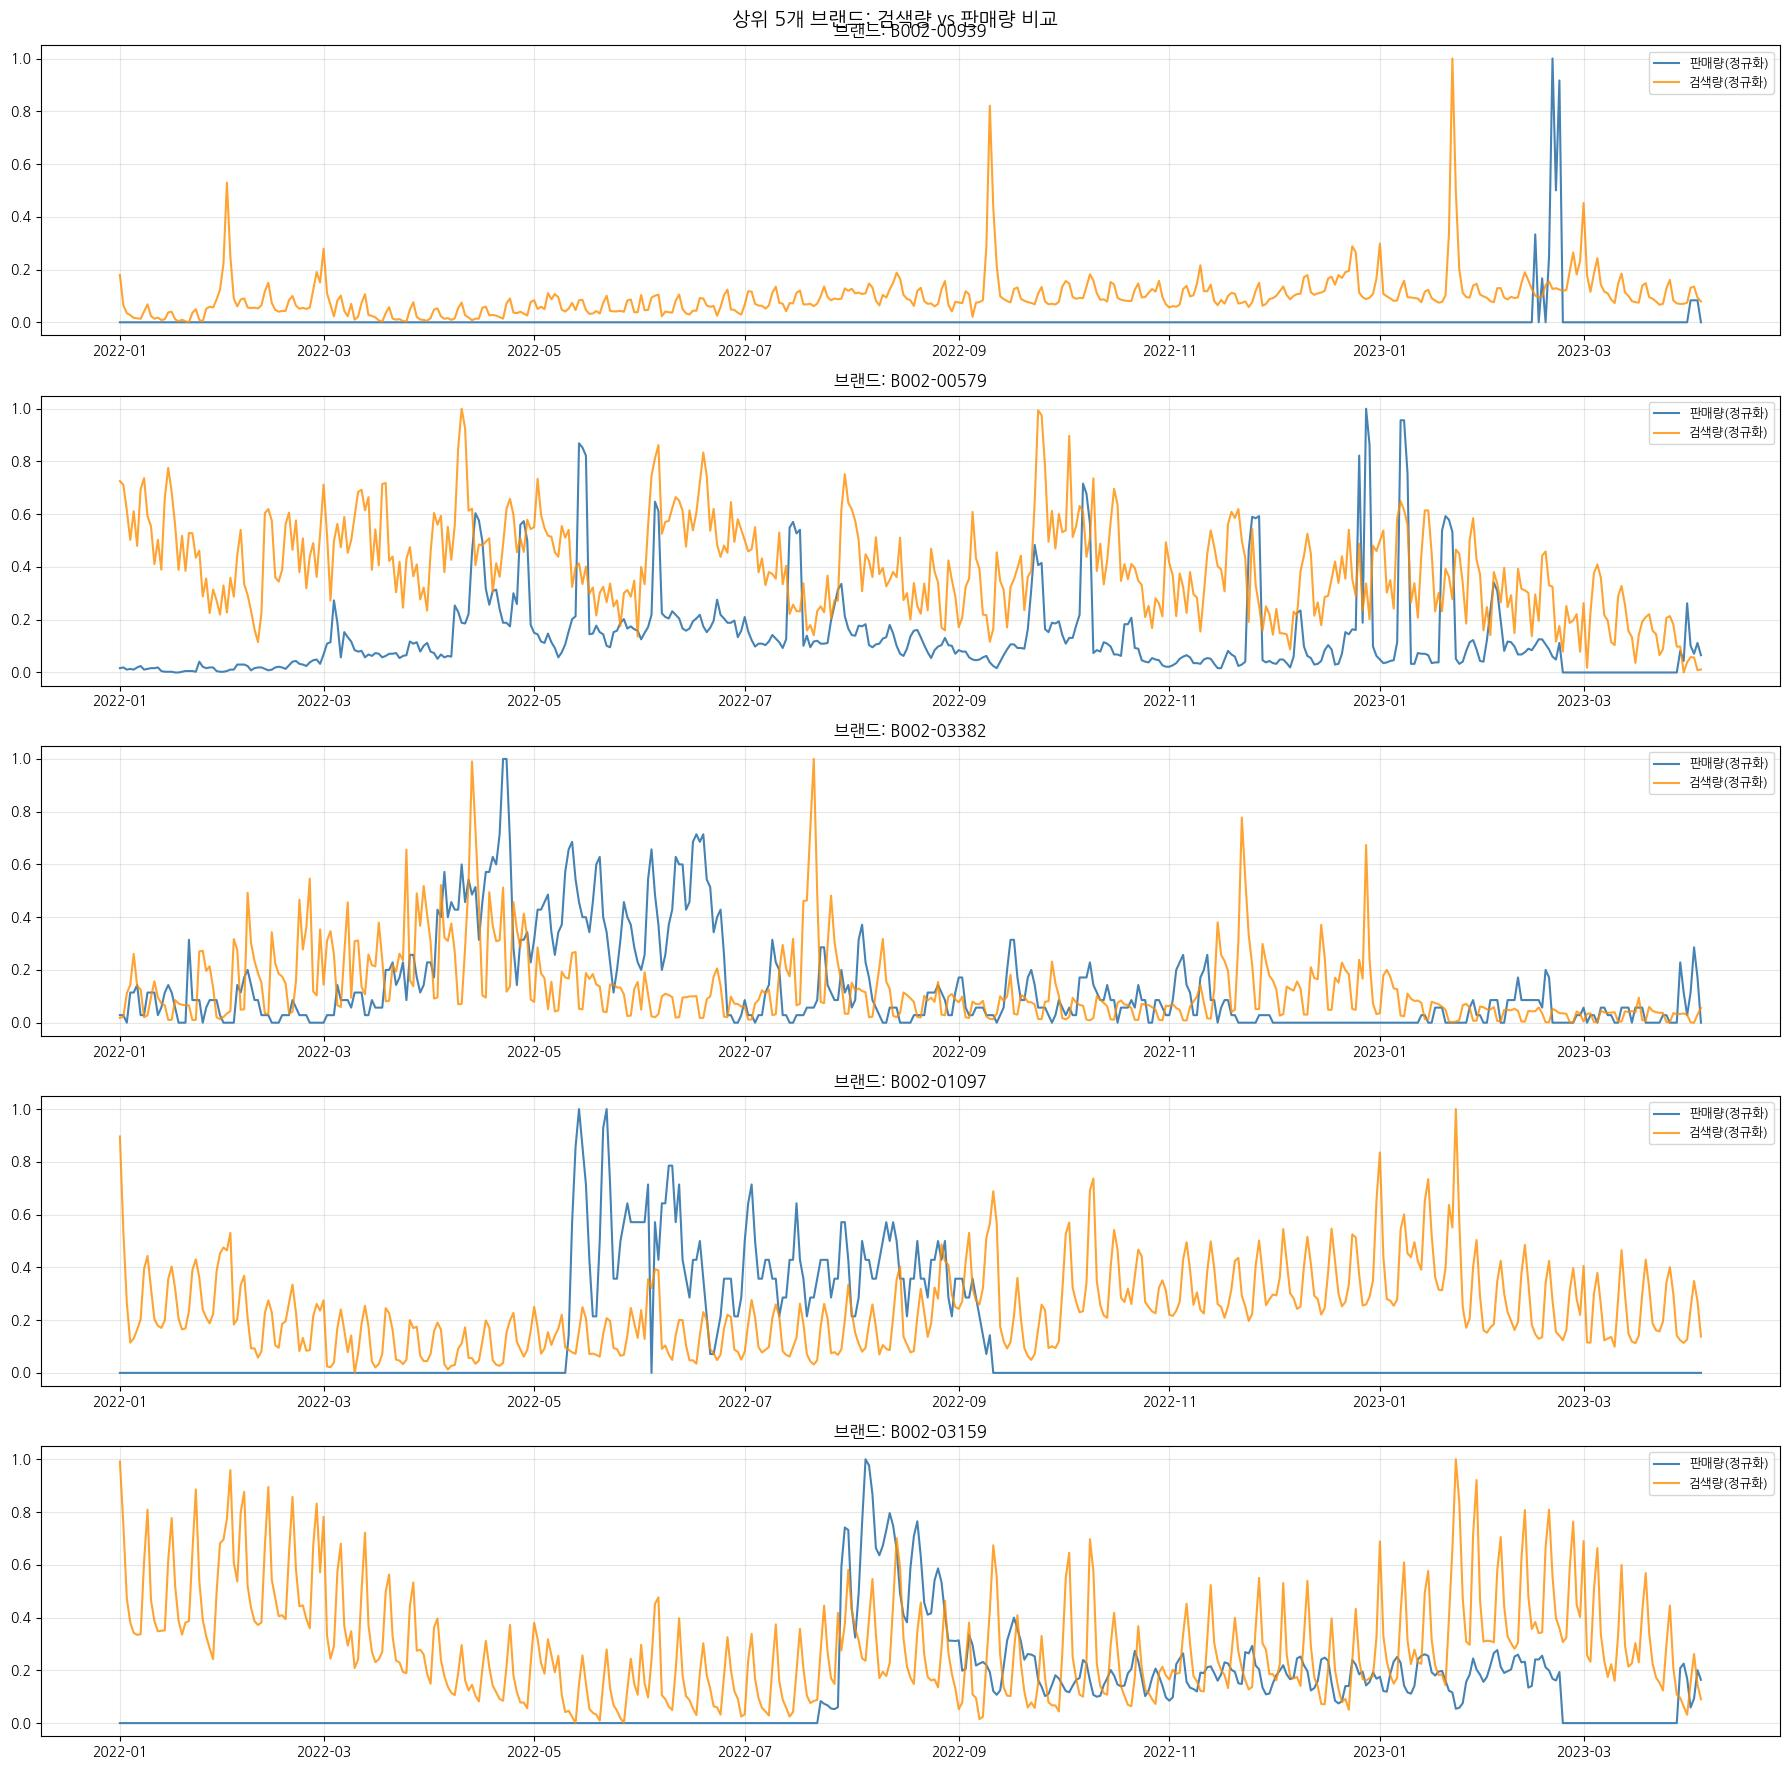

In [18]:
# ── 브랜드 검색량 기본 탐색 ─────────────────────────────────────────────
kw_date_cols = [c for c in keyword.columns if c != '브랜드']
kw_values = keyword[kw_date_cols].values.flatten()
kw_values = kw_values[~np.isnan(kw_values)]

print("=" * 55)
print("📊 brand_keyword_cnt.csv 기본 정보")
print("=" * 55)
print(f"  브랜드 수        : {keyword['브랜드'].nunique():,}개")
print(f"  날짜 수          : {len(kw_date_cols)}일 ({kw_date_cols[0]} ~ {kw_date_cols[-1]})")
print(f"  0인 셀 비율      : {(kw_values == 0).mean():.1%}")
print(f"  NaN 비율         : {keyword[kw_date_cols].isna().values.mean():.1%}")
print(f"  검색량 평균       : {kw_values[kw_values>0].mean():.1f}")
print(f"  검색량 최대       : {kw_values.max():.0f}")

# ── 상위 5개 브랜드의 검색량 vs 판매량 비교 ─────────────────────────────────
# 두 시계열이 비슷하게 움직이면 → 검색량이 선행 지표(예측에 도움)
brand_total_kw = keyword[kw_date_cols].sum(axis=1)
top5_brands = keyword.loc[brand_total_kw.nlargest(5).index, '브랜드'].values

fig, axes = plt.subplots(5, 1, figsize=(18, 18))
fig.suptitle('상위 5개 브랜드: 검색량 vs 판매량 비교', fontsize=14, fontweight='bold')

for i, brand in enumerate(top5_brands):
    ax = axes[i]
    
    # 검색량 시계열
    kw_row = keyword[keyword['브랜드'] == brand][kw_date_cols].iloc[0]
    kw_ts = pd.Series(kw_row.values, index=pd.to_datetime(kw_date_cols))
    
    # 해당 브랜드의 판매량 합계
    brand_qty = train[train['브랜드'] == brand][DATE_COLS].sum(axis=0)
    brand_qty.index = pd.to_datetime(brand_qty.index)
    
    # 두 시계열을 0~1로 정규화해서 같은 그래프에 그리기
    def normalize(s): return (s - s.min()) / (s.max() - s.min() + 1e-8)
    
    ax.plot(normalize(brand_qty), color='steelblue', lw=1.5, label='판매량(정규화)')
    ax.plot(normalize(kw_ts),     color='darkorange', lw=1.5, alpha=0.8, label='검색량(정규화)')
    ax.set_title(f'브랜드: {brand}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# ── 검색량 시차(Lag) 상관관계 분석 ──────────────────────────────────────
# "검색량이 N일 뒤의 판매량을 예측하는가?" 확인
# lag=0: 같은 날, lag=3: 3일 후 판매량과의 상관관계
#
# 분석 방법:
# 브랜드별 (검색량[t], 판매량[t+lag]) 쌍의 상관계수를 계산
# → 전체 브랜드 평균 상관계수가 높으면 유용한 피처

# train 브랜드별 날짜별 판매량
brand_qty_wide  = train.groupby('브랜드')[DATE_COLS].sum()
# keyword 브랜드별 날짜별 검색량 (train 브랜드 순서에 맞게 reindex)
kw_wide = keyword.set_index('브랜드')[kw_date_cols].reindex(brand_qty_wide.index).fillna(0)

lag_list = [0, 1, 3, 7, 14]
corr_results = {}

for lag in lag_list:
    corrs = []
    for brand in brand_qty_wide.index:
        qty_series = brand_qty_wide.loc[brand].values      # 판매량 벡터
        kw_series  = kw_wide.loc[brand].values             # 검색량 벡터
        
        # lag 적용: 검색량을 lag일 앞으로 당기기
        if lag == 0:
            kw_lag = kw_series
            qty_target = qty_series
        else:
            kw_lag     = kw_series[:-lag]   # 검색량: 처음부터 (끝-lag)까지
            qty_target = qty_series[lag:]    # 판매량: lag부터 끝까지
        
        # 분산이 0인 경우(항상 0인 브랜드) 제외
        if kw_lag.std() > 0 and qty_target.std() > 0:
            corr = np.corrcoef(kw_lag, qty_target)[0, 1]
            corrs.append(corr)
    
    corr_results[f'lag_{lag}'] = np.mean(corrs)

print("검색량과 판매량의 시차별 평균 상관계수:")
for lag_name, corr in corr_results.items():
    bar = '█' * int(abs(corr) * 50)
    print(f"  {lag_name:8s}: {corr:+.4f}  {bar}")

print()
print("해석 기준: |상관계수| > 0.3 → 유용, 0.1~0.3 → 보조적, < 0.1 → 미약")


검색량과 판매량의 시차별 평균 상관계수:
  lag_0   : -0.0029  
  lag_1   : +0.0140  
  lag_3   : +0.0204  █
  lag_7   : -0.0090  
  lag_14  : -0.0073  

해석 기준: |상관계수| > 0.3 → 유용, 0.1~0.3 → 보조적, < 0.1 → 미약


#### 💬 1-7 해석 — 검색량 피처 채택 결론

📊 시차별 상관관계 분석 결과

| Lag | 상관계수 | 해석 |
|-----|---------|------|
| 0일 (당일) | -0.003 | 거의 무관 |
| 1일 후 | +0.014 | 거의 무관 |
| 3일 후 | +0.020 | 거의 무관 |
| 7일 후 | -0.009 | 거의 무관 |
| 14일 후 | -0.007 | 거의 무관 |

> 해석 기준: \|상관계수\| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약

전체 평균 상관계수가 **0.02 수준** → 통계적으로는 예측력 거의 없음

---

🔍 그래프에서 발견한 것

- 브랜드마다 검색량-판매량 패턴이 **완전히 다름**
- 일부 브랜드는 특정 구간에서 연동되지만 전체 기간에서는 불규칙
- 검색량은 높은데 판매량은 거의 0인 브랜드 존재 (B002-00939)

---

✅ 채택 결론: **보조 피처로 포함**

통계적 예측력은 약하지만 버리지 않는 이유:

1. **비용이 작음**: 컬럼 3개(`kw_log`, `kw_lag_1`, `kw_lag_3`) 추가가 전부
2. **LSTM에게 맡김**: 평균 상관계수가 낮아도 브랜드별로 유용한 패턴이 있을 수 있음
   → LSTM이 직접 패턴을 찾게 두는 게 우리가 버리는 것보다 나음
3. **없는 것보다 나쁠 수 없음**: 모델이 필요 없다고 판단하면 가중치를 0에 가깝게 학습함

> → STEP 2-6에서 브랜드 × 날짜 기준으로 `kw_log`, `kw_lag_1`, `kw_lag_3` 병합


## 🗺️ EDA 요약 — STEP 2 전처리 결정사항

| 발견 사항 | → | 전처리 결정 |
|----------|---|------------|
| 0이 63.8% (Long Tail) | → | **log1p 변환** |
| 구조적 0 존재 | → | **first_sale_date 이전 마스킹** |
| 49일 미만 활성 제품 4,820개 | → | **학습 제외** |
| 요일 패턴 뚜렷 | → | **day_of_week 피처 추가** |
| Spike 제품 존재 | → | **클리핑 처리** |
| 검색량 보조 신호 | → | **kw_cnt 병합** |
| train(qty) + sales(revenue) | → | **단가(price) 파생** |


---
## STEP 2 — 데이터 전처리 & 피처 엔지니어링

| 순서 | 작업 | 왜 이 순서인가? |
|------|------|----------------|
| 2-1 | Spike 클리핑 | 이후 모든 통계(중앙값, 평균)가 이상치에 오염되지 않도록 **먼저** 처리 |
| 2-2 | 단가(price) 파생 | 클리핑된 qty와 sales로 계산해야 정확함 |
| 2-3 | Wide → Long 변환 | 이후 날짜 기준 조작(lag, join 등)을 위해 필요 |
| 2-4 | 구조적 0 마스킹 | Long 포맷에서 날짜 기준으로 필터링 |
| 2-5 | 카테고리 인코딩 | 텍스트 → 숫자 변환 |
| 2-6 | 검색량 병합 | 브랜드-날짜 기준 join |
| 2-7 | 날짜 피처 생성 | day_of_week, month 등 |
| 2-8 | Log 변환 | 피처들이 다 갖춰진 후 스케일 안정화 |
| 2-9 | Lag & Rolling 피처 | Long 포맷에서 날짜 순서대로 계산 |
| 2-10 | 최종 피처 목록 확정 | 모델 입력 준비 완료 |


### 2-1. Spike 클리핑 — 이상치 제거

In [20]:
# ── Spike 클리핑 처리 ────────────────────────────────────────────────────
# 전략: 각 제품의 중앙값(median) × CLIP_FACTOR 를 상한선으로 설정
# 중앙값을 쓰는 이유: 평균은 이상치 자체에 영향받으므로 더 안정적인 중앙값 사용
#
# CLIP_FACTOR = 20 근거:
# - 정상적인 이벤트(블랙프라이데이, 명절)는 평소 대비 3~10배 정도
# - 20배를 넘어서는 수치가 반복된다면 데이터 오류 가능성 높음
# - 너무 작으면(예: 5배) 실제 이벤트도 깎임 → 20배가 안전한 절충점

CLIP_FACTOR = 20

train_clean = train.copy()  # 원본 보존 → 클린 버전에만 적용

# 각 제품별 중앙값 계산 (판매량이 있는 날만)
product_medians = train_clean[DATE_COLS].median(axis=1)  # 제품별 중앙값

clipped_count = 0  # 몇 개나 클리핑됐는지 카운트

for i, (idx, row_median) in enumerate(product_medians.items()):
    if row_median == 0:
        # 중앙값이 0인 제품: 상한선을 대신 상위 95th 백분위로 설정
        upper_limit = train_clean.loc[idx, DATE_COLS].quantile(0.95)
        if upper_limit == 0:
            continue  # 95th도 0이면 (항상 0인 제품) → 건너뜀
    else:
        upper_limit = row_median * CLIP_FACTOR
    
    # 상한선 초과 셀 수 카운트
    before_max = train_clean.loc[idx, DATE_COLS].max()
    
    # clip(): upper 초과값을 upper로 대체
    train_clean.loc[idx, DATE_COLS] = train_clean.loc[idx, DATE_COLS].clip(upper=upper_limit)
    
    after_max = train_clean.loc[idx, DATE_COLS].max()
    if before_max > after_max:
        clipped_count += 1

print(f"클리핑된 제품 수: {clipped_count:,}개")
print(f"클리핑 전 최대값: {train[DATE_COLS].values.max():,}")
print(f"클리핑 후 최대값: {train_clean[DATE_COLS].values.max():,}")
print()
print("✅ 원본은 train, 클린 버전은 train_clean 으로 별도 보관")


TypeError: Invalid value '12.099999999999966' for dtype 'int64'

### 2-2. 단가(Price) 파생 — revenue ÷ qty

In [ ]:
# ── 단가 파생 논리 ────────────────────────────────────────────────────────
# 단가 = 매출액(sales) ÷ 판매수량(train_clean)
# 단가가 왜 유용한가?
# → 할인 행사 때 단가가 낮아지고 판매량이 뛰는 패턴을 모델이 학습할 수 있음
# → "이 제품이 보통보다 싸게 팔리고 있다" 신호
#
# 주의: qty=0인 날은 나누기 불가 → NaN으로 유지 (이후 보간)

price_df = sales[META_COLS].copy()  # 메타 정보 복사

for col in DATE_COLS:
    qty_col   = train_clean[col]
    sales_col = sales[col]
    
    # qty > 0인 곳만 나누기, 나머지는 NaN
    price_df[col] = np.where(qty_col > 0, sales_col / qty_col, np.nan)

# 단가 NaN 처리: 각 제품별 중앙값으로 채우기 (단가가 0인 날이 없도록)
price_median = price_df[DATE_COLS].median(axis=1)  # 제품별 중앙 단가
for col in DATE_COLS:
    price_df[col] = price_df[col].fillna(price_median)

# 검증
print("단가(price) 파생 검증:")
print(f"  NaN 비율 (중앙값 보간 후): {price_df[DATE_COLS].isna().mean().mean():.4%}")
print(f"  단가 중앙값 (전체): {price_df[DATE_COLS].values.flatten()[~np.isnan(price_df[DATE_COLS].values.flatten())].mean():.1f}원")
print()
print("✅ price_df 생성 완료")


### 2-3. Wide → Long 변환 — 날짜를 행으로 펼치기

이 변환이 **왜 필요한가?**

```
[변환 전 Wide 포맷]              [변환 후 Long 포맷]
ID | 2022-01-01 | 2022-01-02   ID | date       | qty
0  |     5     |     0     →   0  | 2022-01-01 |  5
1  |     0     |    12         0  | 2022-01-02 |  0
                                1  | 2022-01-01 |  0
                                1  | 2022-01-02 | 12
```

Long 포맷이 필요한 이유:
- Lag 피처(어제 판매량, 7일 전 판매량)를 만들려면 날짜가 행이어야 함
- 날짜 기준으로 검색량 데이터를 join하려면 날짜가 행이어야 함
- 날짜 기반 피처(요일, 월 등)를 한 번에 만들 수 있음


In [ ]:
print("Wide → Long 변환 중... (약 30초~1분 소요)")

# pd.melt(): Wide → Long 변환 함수
# id_vars   : 그대로 유지할 컬럼 (제품 메타 정보)
# value_vars: 녹여서 행으로 바꿀 컬럼들 (날짜 컬럼들)
# var_name  : 녹인 컬럼 이름을 담을 새 컬럼명
# value_name: 녹인 값을 담을 새 컬럼명

df = pd.melt(
    train_clean,
    id_vars    = META_COLS,      # ID, 제품, 대분류, 중분류, 소분류, 브랜드 유지
    value_vars = DATE_COLS,      # 날짜 컬럼들을 행으로 변환
    var_name   = 'date',         # 날짜 컬럼명을 담는 새 컬럼
    value_name = 'qty'           # 판매량 값을 담는 새 컬럼
)

# price_df도 동일하게 Long으로 변환
price_long = pd.melt(
    price_df,
    id_vars    = META_COLS,
    value_vars = DATE_COLS,
    var_name   = 'date',
    value_name = 'price'
)

# 날짜 컬럼을 datetime 타입으로 변환 (문자열 → 날짜 객체)
df['date']          = pd.to_datetime(df['date'])
price_long['date']  = pd.to_datetime(price_long['date'])

# df에 price 병합 (ID + date 기준)
df = df.merge(price_long[['ID', 'date', 'price']], on=['ID', 'date'], how='left')

# 정렬: 제품별 날짜 순서로 정렬 (Lag 계산 시 순서가 중요!)
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

print(f"변환 완료!")
print(f"  변환 전 shape: {train_clean.shape}")
print(f"  변환 후 shape: {df.shape}")
print(f"  행 수 = {train_clean.shape[0]:,} 제품 × {len(DATE_COLS)} 날짜 = {train_clean.shape[0]*len(DATE_COLS):,}행")
print()
print(df[['ID', '제품', '대분류', '브랜드', 'date', 'qty', 'price']].head(5).to_string(index=False))


### 2-4. 구조적 0 마스킹 & 희소 제품 제외

In [ ]:
# ══════════════════════════════════════════════════════════════
# 2-4. 구조적 0 마스킹 & days_since_last_sale 피처 생성 (수정)
# ══════════════════════════════════════════════════════════════
#
# [수정 내용]
#   기존: 마지막 판매일 + 90일 이후를 단종으로 간주해 마스킹
#   변경: N일 고정 단종 기준 제거
#         대신 days_since_last_sale 피처를 추가해 모델이 스스로 학습
#
# [왜 바꿨나?]
#   재판매율 분석에서 두 기준일(정상 레짐 vs 레짐 급락 이후) 결과가
#   극단적으로 달랐음 → 어느 N일이 맞는지 데이터가 말해주지 않음
#   → N일을 사람이 결정하는 대신, 모델에게 판단을 위임
#
# [days_since_last_sale 피처의 동작 원리]
#   days_since = 5   → 최근에도 잘 팔림 → 모델: 정상 예측
#   days_since = 200 → 오래 전에 마지막 판매 → 모델: 자연스럽게 0에 가깝게 예측
#   모델이 이 패턴을 학습 데이터에서 스스로 발견함

PRED_START = pd.Timestamp('2023-04-05')  # 예측 시작일

# ── first/last sale date를 df에 병합 ──────────────────────────────────
# EDA 1-5에서 계산한 값 재사용 (Wide 포맷 train 기준)
df = df.merge(
    train[['ID', 'first_sale_date', 'last_sale_date']],
    on='ID', how='left'
)

# ── 구조적 0 마스킹 ────────────────────────────────────────────────────
# 기준: 첫 판매일 이전만 구조적 0으로 처리
# (단종 기준 N일은 제거 → days_since_last_sale 피처로 대체)
df['is_structural_zero'] = (df['date'] < df['first_sale_date'])

# ── (수정) days_since_last_sale 피처 생성 ─────────────────────────────
# "예측 시작일(2023-04-05) 기준으로 이 제품의 마지막 판매일이 며칠 전인가?"
# → 값이 클수록 오래 전에 마지막으로 팔린 것 → 사실상 단종에 가까움
# → 모델이 이 숫자를 보고 예측값을 자연스럽게 조정
df['days_since_last_sale'] = (
    PRED_START - df['last_sale_date']
).dt.days

# 음수 방지: last_sale_date가 PRED_START 이후인 경우 0으로 처리
# (학습 기간 중 최근까지 팔린 제품 → days_since = 0으로 통일)
df['days_since_last_sale'] = df['days_since_last_sale'].clip(lower=0)

# ── 희소 제품(49일 미만 활성) 제외 목록 ──────────────────────────────
# SEQ_LEN(28) + PRED_LEN(21) = 49일: 최소 학습 샘플 1개를 위한 최소 활성 기간
active_days_per_product = (train_clean[DATE_COLS] > 0).sum(axis=1)
EXCLUDE_IDS = set(train_clean.loc[active_days_per_product < 49, 'ID'].values)
EXCLUDE_IDS |= set(train_clean.loc[~has_sales, 'ID'].values)  # 한 번도 안 팔린 제품

print("=" * 55)
print("📊 마스킹 & 제외 결과")
print("=" * 55)
print(f"  전체 행 수                   : {len(df):>10,}")
print(f"  구조적 0으로 마스킹된 행 수  : {df['is_structural_zero'].sum():>10,}")
print(f"  제외 대상 제품 수            : {len(EXCLUDE_IDS):>10,}개")
excluded_rows = df['ID'].isin(EXCLUDE_IDS).sum()
print(f"  제외 대상 제품의 행 수       : {excluded_rows:>10,}")
print()
useful_rows = (~df['is_structural_zero']) & (~df['ID'].isin(EXCLUDE_IDS))
print(f"  실제 학습에 활용 가능한 행   : {useful_rows.sum():>10,}")
print(f"  전체 대비 비율               : {useful_rows.mean():.1%}")
print()
print(f"  days_since_last_sale 분포:")
print(f"    중앙값: {df['days_since_last_sale'].median():.0f}일")
print(f"    평균  : {df['days_since_last_sale'].mean():.0f}일")
print(f"    최대값: {df['days_since_last_sale'].max():.0f}일")


### 2-5. 카테고리 인코딩 — 텍스트 → 숫자

In [ ]:
# ── LabelEncoder: 카테고리 텍스트를 고유한 정수로 변환 ─────────────────────
# 딥러닝 모델은 텍스트를 직접 처리할 수 없습니다.
# 'B002-C001-0002' → 0, 'B002-C001-0003' → 1, ... 처럼 숫자로 바꿔줍니다.
#
# 나중에 Embedding Layer에서 이 숫자를 벡터로 변환합니다.
# (Embedding = 숫자를 의미있는 특성 벡터로 변환하는 레이어)

le_dict = {}  # 나중에 역변환(숫자→텍스트)을 위해 인코더 저장

for col in ['대분류', '중분류', '소분류', '브랜드']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    num_classes = len(le.classes_)
    print(f"  {col:5s}: {num_classes:>5,}개 클래스 → 0~{num_classes-1} 정수로 인코딩")

# 제품 ID도 인코딩 (모델에서 제품별 임베딩에 사용)
le_product = LabelEncoder()
df['product_enc'] = le_product.fit_transform(df['ID'].astype(str))
le_dict['product'] = le_product
print(f"  {'제품':5s}: {len(le_product.classes_):>5,}개 클래스 인코딩")

print()
print("인코딩 결과 확인 (첫 3행):")
enc_cols = ['대분류', '대분류_enc', '중분류', '중분류_enc', '브랜드', '브랜드_enc']
print(df[enc_cols].head(3).to_string(index=False))


### 2-6. 브랜드 검색량 병합 — 브랜드 × 날짜 기준 Join

In [ ]:
# ── keyword Wide → Long 변환 ──────────────────────────────────────────────
kw_date_cols_set = set(kw_date_cols)
train_date_set   = set([str(d.date()) for d in df['date'].unique()])

kw_long = pd.melt(
    keyword,
    id_vars    = ['브랜드'],
    value_vars = kw_date_cols,
    var_name   = 'date',
    value_name = 'kw_cnt'
)
kw_long['date'] = pd.to_datetime(kw_long['date'])
kw_long['kw_cnt'] = kw_long['kw_cnt'].fillna(0)  # NaN → 0 (검색량 없음으로 처리)

# ── 브랜드 + 날짜 기준으로 df에 join ─────────────────────────────────────
df = df.merge(kw_long, on=['브랜드', 'date'], how='left')
df['kw_cnt'] = df['kw_cnt'].fillna(0)  # 검색량 없는 브랜드 → 0

print("검색량 병합 결과:")
print(f"  kw_cnt NaN 비율: {df['kw_cnt'].isna().mean():.4%}")
print(f"  kw_cnt > 0 비율: {(df['kw_cnt'] > 0).mean():.1%}")
print(f"  kw_cnt 평균 (>0): {df.loc[df['kw_cnt']>0, 'kw_cnt'].mean():.1f}")


### 2-7. 날짜 피처 생성 — 요일, 월, 공휴일, 레짐 플래그

**이 단계에서 만드는 피처 목록과 각각의 근거:**

| 피처 | 값 범위 | 근거 |
|------|--------|------|
| `day_of_week` | 0~6 | EDA 1-4에서 목·금·토 고판매 확인 |
| `day_of_month` | 1~31 | 월 내 특정 날짜 패턴(급여일 포함) 포착 |
| `month` | 1~12 | 계절성, 연간 이벤트 패턴 |
| `week_of_year` | 1~52 | 연간 주기성 보조 |
| `is_weekend` | 0/1 | `day_of_week`의 부분집합이지만, EDA에서 **확인된 패턴**을 명시적 힌트로 제공 |
| `is_holiday` | 0/1 | 평일이지만 주말처럼 쉬는 날 → `is_weekend`가 잡지 못하는 공휴일 커버 |
| `is_event` | 0/1 | 이커머스 매출이 튀는 상업적 이벤트(빼빼로데이, 코리아 세일 페스타 등) |
| `days_to_event` | 0~7 | 이벤트 **사전 구매** 패턴 포착 (D-7부터 카운트다운) |
| `is_post_regime` | 0/1 | **2023-02-23 이후 레짐 변화** — 예측 기간이 이 변화 이후이므로 필수 |

> ⚠️ **`is_weekend` 중복 이슈**: `day_of_week(0~6)`가 있으면 논리적으로 `is_weekend`는 파생 가능합니다.
> LSTM은 이를 스스로 학습할 수 있으나, EDA에서 **실증된 패턴**을 명시적 힌트로 주면 학습 속도가 빠릅니다.
> 반면 `is_payday`는 EDA에서 확인하지 않은 가설이므로 제외했습니다. 이 차이가 채택 기준입니다.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 2-7-A. 기본 날짜 피처
# ══════════════════════════════════════════════════════════════════

df['day_of_week']  = df['date'].dt.dayofweek              # 0=월요일, 6=일요일
df['day_of_month'] = df['date'].dt.day                     # 1~31
df['month']        = df['date'].dt.month                   # 1~12
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)  # 1~52

# ── is_weekend ────────────────────────────────────────────────────────────
# day_of_week의 부분집합이지만, EDA에서 확인된 패턴을 명시적 힌트로 제공
# (가설에 불과한 is_payday와 달리, 실증된 패턴이므로 채택)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# ══════════════════════════════════════════════════════════════════
# 2-7-B. 공휴일(is_holiday) — holidays 라이브러리 자동 생성
# ══════════════════════════════════════════════════════════════════
# is_weekend vs is_holiday 차이:
#   is_weekend : 토(5), 일(6)만 커버
#   is_holiday : 평일이지만 쉬는 날 (설날·추석·선거일 등) 커버
#   → 이커머스에서 공휴일은 소비 패턴이 주말에 가깝게 움직임

import holidays as hol

# 2022~2023 한국 공휴일 자동 생성 (임시공휴일 포함)
kr_holidays = hol.KR(years=[2022, 2023])

# 사용자 확인 리스트 + 라이브러리를 합산해 완전한 공휴일 세트 구성
# 라이브러리 검증 결과: 사용자 리스트와 완전 일치 확인됨
holidays_manual = set(map(str, [
    # 2022년 — 공식 공휴일 + 임시공휴일(선거일 2개 포함)
    '2022-01-01',                                               # 신정
    '2022-01-31', '2022-02-01', '2022-02-02',                   # 설날 연휴
    '2022-03-01',                                               # 삼일절
    '2022-03-09',                                               # 제20대 대통령 선거 (임시공휴일)
    '2022-05-05',                                               # 어린이날
    '2022-05-08',                                               # 부처님오신날
    '2022-06-01',                                               # 제8회 지방선거 (임시공휴일)
    '2022-06-06',                                               # 현충일
    '2022-08-15',                                               # 광복절
    '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12',    # 추석 연휴 (12일 대체)
    '2022-10-03',                                               # 개천절
    '2022-10-09', '2022-10-10',                                 # 한글날 + 대체
    '2022-12-25',                                               # 크리스마스
    # 2023년 — 학습 기간(~04-04) + 예측 기간(04-05~04-25) 내 공휴일
    '2023-01-01',                                               # 신정
    '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',    # 설날 연휴 + 대체
    '2023-03-01',                                               # 삼일절
    # ※ 예측 기간(04-05~04-25) 내 공휴일 없음 — 라이브러리 검증 완료
]))

# 라이브러리 자동 날짜와 수동 목록을 합산 (이중 검증)
holidays_lib = set(str(k) for k in kr_holidays.keys()
                   if '2022' <= str(k) <= '2023-04-25')
holidays_all = holidays_manual | holidays_lib

df['is_holiday'] = df['date'].dt.strftime('%Y-%m-%d').isin(holidays_all).astype(int)

print(f"is_holiday 마킹된 날짜 수: {df['is_holiday'].sum():,}행")
print(f"(= {len(holidays_all)}개 공휴일 × 15,890개 제품)")

# ══════════════════════════════════════════════════════════════════
# 2-7-C. 이커머스 상업 이벤트(is_event) + 코리아 세일 페스타
# ══════════════════════════════════════════════════════════════════
# is_holiday와 is_event의 구분:
#   is_holiday : 공식 공휴일 → 배송/물류 영향, 소비 패턴 변화
#   is_event   : 상업적 할인 이벤트 → 수요 급증 직접 원인
#
# 코리아 세일 페스타 2022: 9월 28일 ~ 10월 9일
# ※ 정부 주도 대규모 쇼핑 행사로 이커머스 매출에 직접 영향
#   (공식 날짜는 산업통상자원부 발표 기준 — 연도마다 다를 수 있으므로 확인 권장)

event_dates = {
    # ── 설날 연휴 (연휴 직전 사전 구매 급증) ─────────────────────────
    '2022-01-31': 'seollal', '2022-02-01': 'seollal', '2022-02-02': 'seollal',
    '2023-01-21': 'seollal', '2023-01-22': 'seollal', '2023-01-23': 'seollal',
    # ── 추석 연휴 ──────────────────────────────────────────────────────
    '2022-09-09': 'chuseok', '2022-09-10': 'chuseok',
    '2022-09-11': 'chuseok', '2022-09-12': 'chuseok',
    # ── 어린이날 ───────────────────────────────────────────────────────
    '2022-05-05': 'childrensday',
    # ── 발렌타인데이 / 화이트데이 (초콜릿·선물 카테고리 급증) ─────────
    '2022-02-14': 'valentines', '2023-02-14': 'valentines',
    '2022-03-14': 'whiteday',   '2023-03-14': 'whiteday',
    # ── 빼빼로데이 ─────────────────────────────────────────────────────
    '2022-11-11': 'pepero',
    # ── 블랙프라이데이 (11월 넷째 금요일) ─────────────────────────────
    '2022-11-25': 'blackfriday',
    # ── 코리아 세일 페스타 2022 (9월 28일 ~ 10월 9일) ──────────────────
    # 정부 주도 이커머스 할인 행사 — 전 카테고리 매출 직접 영향
    # ※ 정확한 날짜는 산업통상자원부 공식 발표 기준, 연도별 변동 있음
    '2022-09-28': 'ksf', '2022-09-29': 'ksf', '2022-09-30': 'ksf',
    '2022-10-01': 'ksf', '2022-10-02': 'ksf', '2022-10-03': 'ksf',
    '2022-10-04': 'ksf', '2022-10-05': 'ksf', '2022-10-06': 'ksf',
    '2022-10-07': 'ksf', '2022-10-08': 'ksf', '2022-10-09': 'ksf',
}

df['is_event'] = df['date'].dt.strftime('%Y-%m-%d').map(event_dates).notna().astype(int)

# ── 이벤트까지 남은 날 (사전 구매 패턴, D-7부터 카운트) ──────────────────
# 논리: 빼빼로데이 D-3에 초콜릿을 주문하면 D-0에 도착
#       → D-7부터 D-1까지의 날짜에 미리 주문이 몰리는 패턴
event_dt_list = [pd.Timestamp(d) for d in event_dates.keys()]
df['days_to_event'] = 0
for event_dt in event_dt_list:
    for d in range(1, 8):  # 1~7일 전
        pre_dt = event_dt - pd.Timedelta(days=d)
        df.loc[df['date'] == pre_dt, 'days_to_event'] = d

# ══════════════════════════════════════════════════════════════════
# 2-7-D. 레짐 변화 플래그(is_post_regime)
# ══════════════════════════════════════════════════════════════════
# EDA 1-3에서 확인: 2023-02-23 이후 전체 판매량 레벨이 구조적으로 하락
#
# 왜 피처로 넣어야 하는가?
#   예측 기간(2023-04-05~25)은 이 하락 이후의 새로운 레벨에 해당
#   이 플래그가 없으면 모델이 2022년의 높은 레벨을 기준으로 예측 → 과대예측
#   플래그를 넣으면 "지금은 다른 환경"이라는 맥락을 모델이 학습 가능
#
# REGIME_DATE 근거: EDA 1-3 일별 트렌드에서 전체 판매량 + 활성 제품 수가
# 동시에 급감한 날짜. 단순 spike와 달리 이후 레벨 자체가 유지됨.

REGIME_DATE = pd.Timestamp('2023-02-23')
df['is_post_regime'] = (df['date'] >= REGIME_DATE).astype(int)

# ── 최종 확인 ─────────────────────────────────────────────────────────────
date_feat_cols = ['day_of_week', 'day_of_month', 'month', 'week_of_year',
                  'is_weekend', 'is_holiday', 'is_event', 'days_to_event',
                  'is_post_regime']

print()
print("날짜 피처 생성 완료:")
for col in date_feat_cols:
    n_nonzero = (df[col] > 0).sum()
    print(f"  {col:20s}: 0 아닌 값 {n_nonzero:>8,}행 ({n_nonzero/len(df):.1%})")


### 2-8. product_info 키워드 피처 — 제품 특성 텍스트 활용

In [ ]:
# ── product_info.csv: 제품 특성 텍스트에서 키워드 추출 ─────────────────────
# product_info에는 각 제품의 특성이 텍스트로 있습니다 (예: '다이어트, 저칼로리, 단백질')
# 특정 키워드 유무를 0/1로 변환해 피처로 사용
#
# 주의: product_info는 전체 제품의 66%만 커버 → 나머지 34%는 0으로 처리

product_feat = product.copy()
product_feat['제품특성'] = product_feat['제품특성'].fillna('').astype(str)

# 추출할 키워드 패턴: 유의미한 제품 특성 그룹
pattern_map = {
    'kw_diet'    : r'다이어트|저칼로리|체중|슬림|지방|Diet',
    'kw_protein' : r'단백질|프로틴|Protein|근육|헬스',
    'kw_organic' : r'유기농|천연|자연|무농약|Non-GMO|Organic',
    'kw_kid'     : r'어린이|유아|아기|키즈|Kids|Baby',
    'kw_premium' : r'프리미엄|고급|명품|Premium|럭셔리',
}

for feat_name, pattern in pattern_map.items():
    product_feat[feat_name] = product_feat['제품특성'].str.contains(
        pattern, case=False, na=False, regex=True
    ).astype(int)

# df에 제품 특성 피처 병합 (제품 컬럼 기준)
df = df.merge(
    product_feat[['제품'] + list(pattern_map.keys())],
    on='제품', how='left'
)

# 매칭 안 된 제품(34%)는 NaN → 0으로 채우기
for feat_name in pattern_map.keys():
    df[feat_name] = df[feat_name].fillna(0).astype(int)

match_rate = df['kw_diet'].notna().mean()
print("product_info 키워드 피처 생성 완료:")
for feat_name in pattern_map.keys():
    cnt = df[feat_name].sum()
    print(f"  {feat_name:15s}: {cnt:>8,}행 ({cnt/len(df):.1%})")


### 2-9. Log 변환 — 스케일 안정화

In [ ]:
# ── log1p 변환 ───────────────────────────────────────────────────────────
# np.log1p(x) = log(x + 1)
# x=0 → log(1) = 0  (0도 안전하게 처리)
# x=100 → log(101) ≈ 4.6
# x=200000 → log(200001) ≈ 12.2
# → 0~200,000 범위를 0~12 범위로 압축
#
# ⚠️ 중요: 모델 예측 후 반드시 역변환 필요!
# 역변환: np.expm1(y) = exp(y) - 1

df['qty_log']   = np.log1p(df['qty'])    # 판매량 log 변환 (학습 타겟)
df['price_log'] = np.log1p(df['price'])  # 단가 log 변환 (피처)
df['kw_log']    = np.log1p(df['kw_cnt']) # 검색량 log 변환 (피처)

# 변환 예시 출력
print("log1p 변환 예시:")
print(f"{'원본':>10} → {'변환 후':>10} → {'역변환':>10}")
print("-" * 38)
for x in [0, 1, 10, 100, 1000, 10000]:
    log_val   = np.log1p(x)
    restored  = np.expm1(log_val)
    print(f"{x:>10,} → {log_val:>10.3f} → {restored:>10,.0f}")

print()
print("변환 후 분포 요약 (qty_log):")
print(f"  범위: {df['qty_log'].min():.2f} ~ {df['qty_log'].max():.2f}")
print(f"  평균: {df['qty_log'].mean():.2f}")
print(f"  중앙값: {df['qty_log'].median():.2f}")


### 2-10. Lag & Rolling 피처 — 과거 판매 패턴

> **Lag 피처란?** "어제 얼마나 팔렸나?", "7일 전에 얼마나 팔렸나?"를 피처로 만드는 것입니다.
> **Rolling 피처란?** "최근 7일 평균 판매량"처럼 기간 평균/표준편차를 피처로 만드는 것입니다.

**각 피처를 추가하는 근거:**

| 피처 | 의미 | 근거 |
|------|------|------|
| `qty_lag_1` | 어제 판매량 | 단기 모멘텀 (어제 팔리면 오늘도 팔릴 가능성) |
| `qty_lag_7` | 7일 전 판매량 | 요일 패턴 (7일 주기성이 EDA에서 확인됨) |
| `qty_lag_14` | 14일 전 | 2주 전 같은 요일 패턴 |
| `qty_lag_28` | 28일 전 | 4주 전 패턴 (SEQ_LEN과 같은 기간) |
| `qty_rolling_7_mean` | 최근 7일 평균 | 단기 트렌드 |
| `qty_rolling_28_mean` | 최근 28일 평균 | 중기 수준(level) |
| `qty_rolling_7_std` | 최근 7일 표준편차 | 판매 변동성 (불안정한 제품 감지) |

> ⚠️ **데이터 누수(Leakage) 주의**: Lag 피처 계산 시 반드시 `shift(N)`을 사용해야 합니다.
> `shift(1)`: 오늘의 `qty_lag_1` = 어제(t-1) 판매량. 오늘 판매량(t)은 사용 금지!


In [ ]:
print("Lag & Rolling 피처 생성 중... (약 1~2분 소요)")

# ── 제품별로 시간 순서대로 정렬 후 계산 (이미 정렬됨, 확인 차원) ──────────
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# ── Lag 피처 ─────────────────────────────────────────────────────────────
# shift(N): N행 아래로 밀기 (= N일 전 값을 현재 행에 가져오기)
# groupby('ID'): 제품 경계를 넘지 않도록 제품별로 계산

for lag in [1, 7, 14, 28]:
    # qty_log 기준 lag (log 스케일로 계산해야 일관성)
    df[f'qty_lag_{lag}'] = df.groupby('ID')['qty_log'].shift(lag)

# ── Rolling(이동 통계) 피처 ────────────────────────────────────────────────
# rolling(window, min_periods): window 크기의 이동 통계
# min_periods=1: 데이터가 window보다 적을 때도 계산 (초반 NaN 방지)
# shift(1): 오늘 데이터 포함 방지 (오늘 판매량으로 오늘을 예측하는 누수 방지)

for window in [7, 28]:
    df[f'qty_rolling_{window}_mean'] = (
        df.groupby('ID')['qty_log']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

df['qty_rolling_7_std'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std().fillna(0))
)

# ── 검색량 Lag 피처 (브랜드 단위) ────────────────────────────────────────
for lag in [1, 3]:
    df[f'kw_lag_{lag}'] = df.groupby('브랜드')['kw_log'].shift(lag)

# ── NaN 채우기 ─────────────────────────────────────────────────────────────
# Lag 피처의 초반 N행은 계산 불가 → 해당 제품의 중앙값으로 채우기
lag_feat_cols = [c for c in df.columns if 'lag_' in c or 'rolling_' in c]
for col in lag_feat_cols:
    # 제품별 중앙값으로 채우기 (전체 0보다 현실적)
    df[col] = df.groupby('ID')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(0)  # 중앙값도 NaN인 경우(모두 NaN) → 0

print("Lag & Rolling 피처 생성 완료!")
print(f"추가된 피처 수: {len(lag_feat_cols)}개")
print("피처 목록:", lag_feat_cols)
print()

# 텐서 Shape 추적 예시
print("=" * 55)
print("📐 데이터 차원 변화 추적 (Tensor Shape 미리보기)")
print("=" * 55)
print(f"  현재 df shape: {df.shape}")
print(f"  = {df['ID'].nunique():,}개 제품 × {len(DATE_COLS)}일 = {df['ID'].nunique()*len(DATE_COLS):,}행")
print()
print("  모델 입력 시 shape:")
print("  (Batch, SEQ_LEN, N_FEAT) = (?, 28, ?)")
print("  N_FEAT는 아래 최종 피처 목록에서 확정됩니다")


### 2-11. 최종 피처 목록 확정 & 전처리 완료 확인

In [ ]:
# ── 최종 피처 목록 정의 ─────────────────────────────────────────────────
# 이 목록이 모델의 입력(X)이 됩니다
# 타겟(y) = qty_log (예측 대상)

FEATURE_COLS = [
    # ── 카테고리 피처 (임베딩 입력용 정수) ──────────────────────────────
    '대분류_enc',        # 5개 클래스
    '중분류_enc',        # 11개 클래스
    '소분류_enc',        # 53개 클래스
    '브랜드_enc',        # 3,170개 클래스

    # ── 날짜 피처 (주기성, 이벤트) ───────────────────────────────────────
    'day_of_week',       # 0~6 (요일)
    'day_of_month',      # 1~31
    'month',             # 1~12
    'week_of_year',      # 1~52
    # ── is_weekend 설계 노트 ─────────────────────────────────────────────
    # day_of_week(0~6)의 부분집합이므로 이론상 중복
    # 단, EDA에서 실증된 패턴을 명시적 힌트로 제공 → 학습 속도 보조
    # (EDA 미검증 가설인 is_payday와의 채택 기준 차이)
    'is_weekend',        # 0/1 — 토·일 (day_of_week의 확인된 패턴 힌트)
    'is_holiday',        # 0/1 — 공식 공휴일 (is_weekend가 못 잡는 평일 공휴일)
    'is_event',          # 0/1 — 상업 이벤트 (코리아 세일 페스타, 빼빼로데이 등)
    'days_to_event',     # 0~7 — 이벤트까지 남은 날 (사전 구매 패턴)
    'is_post_regime',    # 0/1 — 2023-02-23 이후 레짐 변화 (예측 기간이 이 이후)

    # ── 판매량 Lag 피처 (과거 판매 패턴) ─────────────────────────────────
    'qty_lag_1',         # 어제 판매량(log)
    'qty_lag_7',         # 7일 전 판매량(log) — 요일 패턴 핵심
    'qty_lag_14',        # 14일 전 판매량(log)
    'qty_lag_28',        # 28일 전 판매량(log)

    # ── 이동 통계 피처 (추세, 안정성) ────────────────────────────────────
    'qty_rolling_7_mean',   # 최근 7일 평균 — 단기 트렌드
    'qty_rolling_28_mean',  # 최근 28일 평균 — 중기 수준
    'qty_rolling_7_std',    # 최근 7일 변동성

    # ── 가격 피처 ─────────────────────────────────────────────────────────
    'price_log',         # 단가(log) — 할인 이벤트 감지

    # ── 브랜드 검색량 피처 ────────────────────────────────────────────────
    'kw_log',            # 당일 검색량(log)
    'kw_lag_1',          # 1일 전 검색량(log)
    'kw_lag_3',          # 3일 전 검색량(log)

    # ── 제품 특성 키워드 피처 ─────────────────────────────────────────────
    'kw_diet',           # 다이어트 제품 여부
    'kw_protein',        # 단백질 제품 여부
    'kw_organic',        # 유기농 여부
    'kw_kid',            # 어린이 제품 여부
    'kw_premium',        # 프리미엄 제품 여부
]

TARGET_COL  = 'qty_log'   # 모델이 예측할 타겟
ID_COL      = 'ID'
DATE_COL    = 'date'
SEQ_LEN     = 28          # 입력 시퀀스 길이 (28일)
PRED_LEN    = 21          # 출력 예측 길이 (21일)

# ── 실제로 df에 모두 존재하는지 확인 ─────────────────────────────────────
missing_feats = [f for f in FEATURE_COLS if f not in df.columns]
if missing_feats:
    print(f"⚠️ 누락된 피처: {missing_feats}")
else:
    print("✅ 모든 피처 확인 완료")

print()
print("=" * 55)
print("📐 최종 텐서 Shape 정의")
print("=" * 55)

print(f"  입력 시퀀스(SEQ) : {SEQ_LEN}일")
print(f"  예측 길이(PRED)  : {PRED_LEN}일")
print()
print("  LSTM 모델 입출력:")
print(f"  입력 X : (Batch, {SEQ_LEN}, {N_FEAT})")
print(f"  출력 y : (Batch, {PRED_LEN})")
print()
print("  ※ Batch 크기는 하이퍼파라미터로 학습 시 결정됩니다")

In [ ]:
# ── 최종 전처리된 데이터 요약 ────────────────────────────────────────────
print("=" * 55)
print("🏁 전처리 최종 요약")
print("=" * 55)

# 학습 가능한 제품 (구조적 0 제거 + 희소 제품 제외)
train_mask = (~df['is_structural_zero']) & (~df['ID'].isin(EXCLUDE_IDS))
df_train = df[train_mask].copy()

print(f"  전처리 후 학습 데이터 행 수: {len(df_train):>10,}")
print(f"  학습 대상 제품 수          : {df_train['ID'].nunique():>10,}개")
print(f"  날짜 범위                  : {df_train['date'].min().date()} ~ {df_train['date'].max().date()}")
print()
print(f"  입력 피처 수: {len(FEATURE_COLS)}개")
print(f"  타겟: {TARGET_COL} (예측 후 np.expm1으로 역변환)")
print()

# NaN 체크
nan_check = df_train[FEATURE_COLS + [TARGET_COL]].isna().sum()
nan_cols = nan_check[nan_check > 0]
if len(nan_cols) == 0:
    print("  ✅ 모든 피처에 NaN 없음")
else:
    print("  ⚠️ NaN이 남아있는 피처:")
    print(nan_cols)

print()
print("다음 단계 → STEP 3: Dataset 클래스 + LSTM 모델 구성")
print("  슬라이딩 윈도우로 (X, y) 쌍 생성 후 DataLoader에 넣기")


In [ ]:
# ── 학습/검증 분할 기준 ─────────────────────────────────────────────────
# 시계열 데이터는 랜덤 분할 금지!
# 이유: 미래 데이터로 과거를 예측하는 '데이터 누수' 발생
#
# 방법: 날짜 기준으로 앞쪽 = 학습, 뒤쪽 = 검증
#
# 학습 기간: 2022-01-01 ~ 2023-02-28
# 검증 기간: 2023-03-01 ~ 2023-04-04
# 예측 기간: 2023-04-05 ~ 2023-04-25 (제출 대상)
#
# 검증 기간 선택 근거:
# - 2023-03의 구조적 변화(레벨 하락)를 학습에 반영하면서
# - 동시에 예측 기간(04-05~04-25) 직전 데이터로 검증

TRAIN_END   = pd.Timestamp('2023-02-28')
VAL_START   = pd.Timestamp('2023-03-01')
PRED_START  = pd.Timestamp('2023-04-05')
PRED_END    = pd.Timestamp('2023-04-25')

train_data = df_train[df_train['date'] <= TRAIN_END]
val_data   = df_train[df_train['date'] >= VAL_START]

print("=" * 55)
print("📅 학습/검증 분할 결과")
print("=" * 55)
print(f"  학습 기간: {train_data['date'].min().date()} ~ {train_data['date'].max().date()}")
print(f"  학습 행 수: {len(train_data):>10,}")
print()
print(f"  검증 기간: {val_data['date'].min().date()} ~ {val_data['date'].max().date()}")
print(f"  검증 행 수: {len(val_data):>10,}")
print()
print(f"  예측 기간: {PRED_START.date()} ~ {PRED_END.date()} (21일)")
print()
print("✅ 전처리 완료! df_train, train_data, val_data 준비됨")


---
## 📋 전체 전처리 파이프라인 요약

```
원본 데이터 (train.csv, sales.csv, keyword.csv, product_info.csv)
    │
    ├── [2-1] Spike 클리핑 (중앙값 × 20)
    │         → 데이터 오류로 추정되는 이상치 제거
    │
    ├── [2-2] 단가 파생 (sales ÷ train)
    │         → 할인 이벤트 감지 피처
    │
    ├── [2-3] Wide → Long 변환 (15,890행 × 459열 → 7,293,510행 × N열)
    │         → 이후 모든 날짜 기반 조작의 기반
    │
    ├── [2-4] 구조적 0 마스킹 + 희소 제품(49일 미만) 제외
    │         → 실제 학습 가능한 데이터만 남김
    │
    ├── [2-5] 카테고리 인코딩 (LabelEncoder)
    │         → 텍스트 → 정수 → 이후 Embedding Layer로 벡터화
    │
    ├── [2-6] 검색량 병합 (브랜드 × 날짜 join)
    │
    ├── [2-7] 날짜 피처 (요일, 월, is_holiday, is_event[코리아 세일 페스타 포함],
    │          is_post_regime[2023-02-23 레짐 변화 플래그])
    │
    ├── [2-8] product_info 키워드 피처
    │
    ├── [2-9] log1p 변환 (qty, price, kw_cnt)
    │         → 0~200,000 → 0~12 압축
    │
    ├── [2-10] Lag & Rolling 피처 (lag_1/7/14/28, rolling_7/28_mean/std)
    │          → 과거 패턴 직접 입력
    │
    └── [2-11] 피처 목록 확정: N_FEAT = 29개
              입력 shape: (Batch, 28, 29)
              출력 shape: (Batch, 21)
```

> **다음 단계 (STEP 3)**: 이 `df_train`을 가지고
> PyTorch `Dataset` 클래스에서 슬라이딩 윈도우로 (X, y) 쌍을 만들고
> LSTM 모델을 학습시킵니다.


### 📐 임베딩 차원 결정
#원래 #하나더 
임베딩 차원 공식: `min(50, (n_classes // 2) + 1)`
- Keras 등 실무에서 검증된 경험칙: "클래스 수의 절반"이 과적합 없이 안정적

| 카테고리 | 클래스 수 | 공식 적용 | 채택 차원 |
|---------|---------|---------|---------|
| 대분류 | 5개 | (5//2)+1 = 3 | **3차원** |
| 중분류 | 11개 | (11//2)+1 = 6 | **6차원** |
| 소분류 | 53개 | (53//2)+1 = 27 | **27차원** |
| 브랜드 | 3,170개 | 50 → 분석 후 축소 | **32차원** |

브랜드 32차원 근거 → 아래 셀 참고

In [ ]:
# # ══════════════════════════════════════════════════════
# # 브랜드 임베딩 차원 결정을 위한 판매 집중도 분석
# # ══════════════════════════════════════════════════════

# DATE_COLS = [c for c in train.columns if c.startswith('20')]

# # 1단계: 브랜드별 총 판매량 계산 → 많이 판 순서로 정렬
# brand_sales = train.groupby('브랜드')[DATE_COLS].sum().sum(axis=1).sort_values(ascending=False)
# total_sales = brand_sales.sum()
# total_brands = len(brand_sales)  # 전체 브랜드 수 (하드코딩 X, 직접 계산)

# # 2단계: 누적 판매 비율 계산
# cumsum_pct = brand_sales.cumsum() / total_sales * 100

# # 3단계: 군소 브랜드 기준 → 제품 1~2개인 브랜드 수를 직접 계산
# brand_product_cnt = train.groupby('브랜드')['제품'].nunique()
# tiny_brands = (brand_product_cnt <= 2).sum()          # 군소 브랜드 수
# tiny_pct = tiny_brands / total_brands * 100            # 군소 브랜드 비율

# print("=== 브랜드 판매 집중도 ===")
# # 10, 50, 100은 임의의 둥근 숫자 / tiny_brands는 직접 계산한 값
# for n in [10, 50, 100, tiny_brands]:
#     print(f"상위 {n:4d}개 브랜드가 전체 판매의 {cumsum_pct.iloc[n-1]:.1f}% 차지")

# print()
# print(f"군소 브랜드 {tiny_brands}개({tiny_pct:.1f}%)가 전체 판매의 {100 - cumsum_pct.iloc[tiny_brands-1]:.1f}% 차지")

# print()
# print("=== 임베딩 차원 결정 기준 ===")
# print(f"전체 브랜드 {total_brands}개 중 군소 브랜드 {tiny_brands}개({tiny_pct:.1f}%) = 판매 극소수")
# print("→ 군소 브랜드에 큰 차원 낭비할 필요 없음")
# print("→ 결론: 32차원 채택")



[상위 10개  ]   ████████████████████████████████████ 35.0%  
[11~50개    ]  ████████████████████████             24.4%  
[51~100개   ]  ██████████                           10.7%  
[101~2032개 ]  ████████████████████                 29.7%  
[2033~3170개] ░                                      0.2%  ← 군소 브랜드  

* 브랜드의 64%가 판매의 0.2% → 이들을 위한 큰 임베딩은 낭비
* 브랜드 32차원으로